# Predicción del rendimiento agrícola (toneladas por hectárea)
### Proyecto final de Machine Learning · Regresión supervisada

**Pregunta central:** ¿se puede predecir el rendimiento agrícola en toneladas por hectárea (`yield_ton_ha`) a partir de las características del suelo y las condiciones ambientales usando modelos de Machine Learning?

Este cuaderno sigue el flujo completo, de principio a fin: cargar y entender los datos, revisar su calidad, limpiarlos, separar entrenamiento y prueba, preprocesar dentro de un pipeline, entrenar siete modelos de regresión, compararlos, elegir uno, interpretarlo y dejarlo guardado para la app de Streamlit.

El objetivo es **regresión**. La columna `label` (cultivo recomendado) no se usa para clasificar nada y, como se verá, tampoco como predictora.

**Cómo ejecutarlo en Google Colab:** sube `Crop_Agriculture.csv` cuando la celda de carga lo pida y ejecuta todo en orden (*Entorno de ejecución → Ejecutar todo*). Al final se generan el modelo, sus metadatos y un `.zip` listo para llevarlo al repositorio.

## 0. Librerías y configuración

In [1]:
import json
import platform
import sys
import time
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from scipy import stats

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import (mean_absolute_error, mean_absolute_percentage_error,
                             mean_squared_error, r2_score)
from sklearn.model_selection import (GridSearchCV, KFold, cross_val_predict,
                                     cross_validate, train_test_split)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR

try:  # en algunas versiones de scikit-learn hay que habilitarlo de forma explícita
    from sklearn.experimental import enable_iterative_imputer  # noqa: F401
except ImportError:
    pass
from sklearn.impute import IterativeImputer

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 11})
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# Rutas: funciona igual en Colab (carpeta actual) y en el repositorio (carpeta notebooks/)
ROOT = Path("..") if Path("../data/Crop_Agriculture.csv").exists() else Path(".")
DATA_DIR, MODEL_DIR, FIG_DIR = ROOT / "data", ROOT / "models", ROOT / "reports" / "figures"
for carpeta in (DATA_DIR, MODEL_DIR, FIG_DIR):
    carpeta.mkdir(parents=True, exist_ok=True)


def guardar_fig(nombre):
    """Guarda la figura actual (se usa luego en el README) antes de mostrarla."""
    plt.savefig(FIG_DIR / f"{nombre}.png", dpi=140, bbox_inches="tight")


print(f"Python {platform.python_version()} | pandas {pd.__version__} | numpy {np.__version__} | scikit-learn {sklearn.__version__}")

Python 3.13.16 | pandas 3.0.5 | numpy 2.5.3 | scikit-learn 1.9.1


## 1. Carga del dataset

In [2]:
candidatas = [Path("Crop_Agriculture.csv"), DATA_DIR / "Crop_Agriculture.csv"]
ruta = next((p for p in candidatas if p.exists()), None)

if ruta is None:  # Colab: pedir el archivo
    try:
        from google.colab import files
        subido = files.upload()
        ruta = Path(next(iter(subido)))
    except ImportError:
        raise FileNotFoundError("No encuentro Crop_Agriculture.csv. Colócalo junto al cuaderno o en data/.")

df_raw = pd.read_csv(ruta)
print(f"Archivo cargado: {ruta}")
df_raw.head()

Archivo cargado: ../data/Crop_Agriculture.csv


,RecordID,FullName,Phone,ZodiacSign,FavoriteColor,Hobby,N,P,K,temperature,humidity,ph,rainfall,rainfall_inches,soil_type,FarmID,Country,yield_ton_ha,label
0,REC00001,Laura Johnson,"3,878,345,466.000",Virgo,Green,Travel,69.000,NaN,199.000,10.705,61.143,NaN,36.445,1.435,Chalky,F92,Other,4.842,cotton
1,REC00002,Sofia Lopez,"3,805,983,682.000",Gemini,White,Hiking,NaN,15.000,16.000,27.075,42.015,6.207,250.961,9.880,Silty,F113,Colombia,2.250,wheat
2,REC00003,Richard Miller,"3,317,422,619.000",Taurus,Black,Dancing,68.000,106.000,179.000,11.491,88.012,8.669,173.259,6.821,Type3,F165,Colombia,3.853,apple
3,REC00004,Marta Brown,"3,880,709,177.000",Sagittarius,White,Hiking,21.000,65.000,193.000,19.646,36.216,5.459,63.970,2.518,Silty,F110,Colombia,3.967,apple
4,REC00005,John Johnson,"3,612,618,177.000",Pisces,White,Photography,135.000,61.000,26.000,15.091,81.609,7.867,163.214,6.426,Type10,F189,Colombia,3.733,grapes


## 2. Análisis de variables

Primero lo básico: tamaño, nombres, tipos, nulos, duplicados y estadísticas descriptivas. Todavía no se toca nada; `df_raw` queda como copia fiel del archivo original.

In [3]:
print(f"Filas: {df_raw.shape[0]:,}  |  Columnas: {df_raw.shape[1]}\n")
print("Columnas:", list(df_raw.columns))
df_raw.dtypes.rename("tipo").to_frame()

Filas: 1,200  |  Columnas: 19

Columnas: ['RecordID', 'FullName', 'Phone', 'ZodiacSign', 'FavoriteColor', 'Hobby', 'N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'rainfall_inches', 'soil_type', 'FarmID', 'Country', 'yield_ton_ha', 'label']


,tipo
RecordID,str
FullName,str
Phone,float64
ZodiacSign,str
FavoriteColor,str
Hobby,str
N,float64
P,float64
K,float64
temperature,float64


In [4]:
nulos = pd.DataFrame({"nulos": df_raw.isna().sum(), "porcentaje": df_raw.isna().mean() * 100})
nulos = nulos[nulos["nulos"] > 0].sort_values("nulos", ascending=False)
filas_con_nulo = df_raw.isna().any(axis=1).sum()

print(f"Filas con al menos un nulo: {filas_con_nulo} de {len(df_raw)} ({filas_con_nulo / len(df_raw):.1%})")
print(f"Duplicados exactos: {df_raw.duplicated().sum()}  |  duplicados ignorando RecordID: {df_raw.drop(columns='RecordID').duplicated().sum()}")
nulos

Filas con al menos un nulo: 518 de 1200 (43.2%)
Duplicados exactos: 0  |  duplicados ignorando RecordID: 0


,nulos,porcentaje
P,132,11.000
soil_type,132,11.000
temperature,132,11.000
N,124,10.333
ph,124,10.333


In [5]:
cols_num = df_raw.select_dtypes(include="number").columns.tolist()
cols_cat = df_raw.select_dtypes(exclude="number").columns.tolist()
print("Numéricas :", cols_num)
print("Categóricas:", cols_cat)
df_raw[cols_num].describe().T

Numéricas : ['Phone', 'N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'rainfall_inches', 'yield_ton_ha']
Categóricas: ['RecordID', 'FullName', 'ZodiacSign', 'FavoriteColor', 'Hobby', 'soil_type', 'FarmID', 'Country', 'label']


,count,mean,std,min,25%,50%,75%,max
Phone,"1,200.000","3,502,140,338.940","294,163,571.487","3,000,728,183.000","3,257,348,620.750","3,488,506,773.500","3,757,920,273.750","3,999,969,490.000"
N,"1,076.000",71.017,47.892,-20.000,35.000,70.000,104.000,500.000
P,"1,068.000",75.256,40.988,5.000,40.000,75.000,111.000,144.000
K,"1,200.000",101.945,57.609,5.000,53.000,99.000,152.250,204.000
temperature,"1,068.000",25.481,8.649,10.110,18.345,25.539,32.696,39.954
humidity,"1,200.000",57.385,21.779,20.118,37.802,57.658,76.025,94.924
ph,"1,076.000",6.530,1.557,0.500,5.195,6.575,7.790,14.000
rainfall,"1,200.000",170.111,132.828,-10.000,92.546,165.907,233.760,"2,000.000"
rainfall_inches,"1,200.000",6.478,3.141,1.185,3.654,6.521,9.195,11.795
yield_ton_ha,"1,200.000",3.875,0.772,1.268,3.334,3.880,4.407,6.021


In [6]:
cardinalidad = pd.DataFrame({
    "valores_unicos": df_raw[cols_cat].nunique(),
    "pct_unicos": df_raw[cols_cat].nunique() / len(df_raw) * 100,
    "categoria_mas_frecuente": df_raw[cols_cat].agg(lambda s: s.value_counts().index[0]),
    "pct_categoria_top": df_raw[cols_cat].agg(lambda s: s.value_counts(normalize=True).iloc[0] * 100),
}).sort_values("valores_unicos", ascending=False)
cardinalidad

,valores_unicos,pct_unicos,categoria_mas_frecuente,pct_categoria_top
RecordID,1200,100.000,REC00001,0.083
FullName,378,31.500,Charles Martinez,0.750
FarmID,199,16.583,F36,1.000
label,23,1.917,cotton,5.333
soil_type,22,1.833,Type11,5.618
ZodiacSign,12,1.000,Scorpio,9.500
FavoriteColor,10,0.833,Pink,11.167
Hobby,10,0.833,Sports,12.000
Country,2,0.167,Colombia,96.000


**Lo que dice esta primera mirada.** Son 1.200 filas y 19 columnas, sin duplicados. Faltan datos en cinco variables (`N`, `P`, `temperature`, `ph` y `soil_type`), entre 124 y 132 por columna, y esos huecos caen en filas distintas: 518 filas, el 43 %, tienen al menos un dato faltante. Eso ya descarta de entrada la idea de borrar filas incompletas, porque nos quedaríamos con poco más de la mitad del dataset.

`pandas` clasifica `Phone` como numérica, pero es un número de teléfono y no una medida; conviene tenerlo presente. En cuanto a cardinalidad, `RecordID` es único en todas las filas, `FullName` tiene 378 valores, `FarmID` 199, `label` 23 y `soil_type` 22. `Country` es lo contrario: el 96 % de las filas son de Colombia.

## 3. Análisis exploratorio (EDA)

### 3.1 La variable objetivo

Antes de modelar hay que saber cómo se comporta lo que queremos predecir: su forma, si es simétrica, si tiene colas raras. De eso depende, por ejemplo, si tendría sentido transformarla.

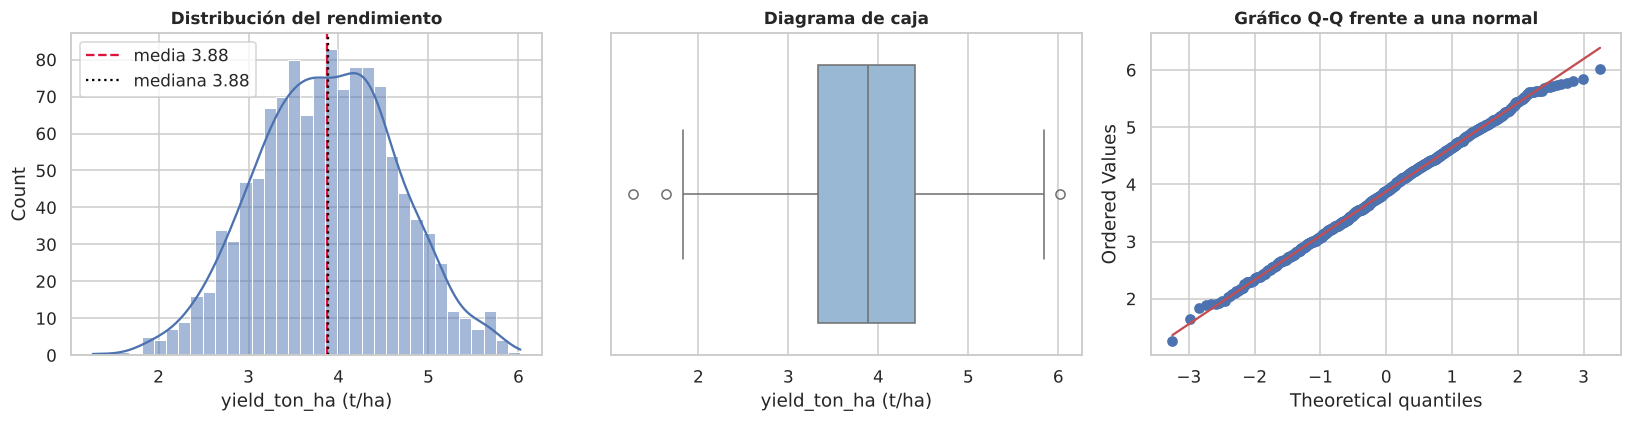

,n,media,mediana,desv. estándar,mínimo,máximo,asimetría,curtosis (exceso)
yield_ton_ha,"1,200.000",3.875,3.880,0.772,1.268,6.021,-0.038,-0.242


In [7]:
y_raw = df_raw["yield_ton_ha"]
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(y_raw, kde=True, bins=35, ax=ax[0], color="#4C72B0")
ax[0].axvline(y_raw.mean(), color="crimson", ls="--", label=f"media {y_raw.mean():.2f}")
ax[0].axvline(y_raw.median(), color="black", ls=":", label=f"mediana {y_raw.median():.2f}")
ax[0].set(title="Distribución del rendimiento", xlabel="yield_ton_ha (t/ha)")
ax[0].legend()

sns.boxplot(x=y_raw, ax=ax[1], color="#8FB8DE")
ax[1].set(title="Diagrama de caja", xlabel="yield_ton_ha (t/ha)")

stats.probplot(y_raw, dist="norm", plot=ax[2])
ax[2].set_title("Gráfico Q-Q frente a una normal")
plt.tight_layout(); guardar_fig("01_distribucion_objetivo"); plt.show()

resumen_y = pd.Series({
    "n": len(y_raw), "media": y_raw.mean(), "mediana": y_raw.median(), "desv. estándar": y_raw.std(),
    "mínimo": y_raw.min(), "máximo": y_raw.max(), "asimetría": y_raw.skew(), "curtosis (exceso)": y_raw.kurt(),
}, name="yield_ton_ha")
resumen_y.to_frame().T

El rendimiento se comporta bien. La media (3,875 t/ha) y la mediana (3,880) casi coinciden, la asimetría es −0,04 y el exceso de curtosis −0,24, es decir, una campana prácticamente simétrica y algo más plana que la normal. En el gráfico Q-Q los puntos siguen la recta salvo un poco en las colas. Va de 1,27 a 6,02 t/ha con una desviación estándar de 0,77.

Dos consecuencias prácticas: no hace falta transformar el objetivo (ni logaritmo ni nada parecido), y el valor de referencia para juzgar a los modelos es esa desviación de 0,77: un modelo que siempre predijera la media se equivocaría en torno a 0,77 t/ha. Los tres puntos que el diagrama de caja marca como atípicos están en las colas de una distribución simétrica, así que son parcelas con rendimiento muy alto o muy bajo, no errores.

### 3.2 Forma de las variables numéricas

Un histograma por variable sirve para ver rangos, simetría y si hay valores aislados lejos del resto. También deja ver si las escalas son muy distintas.

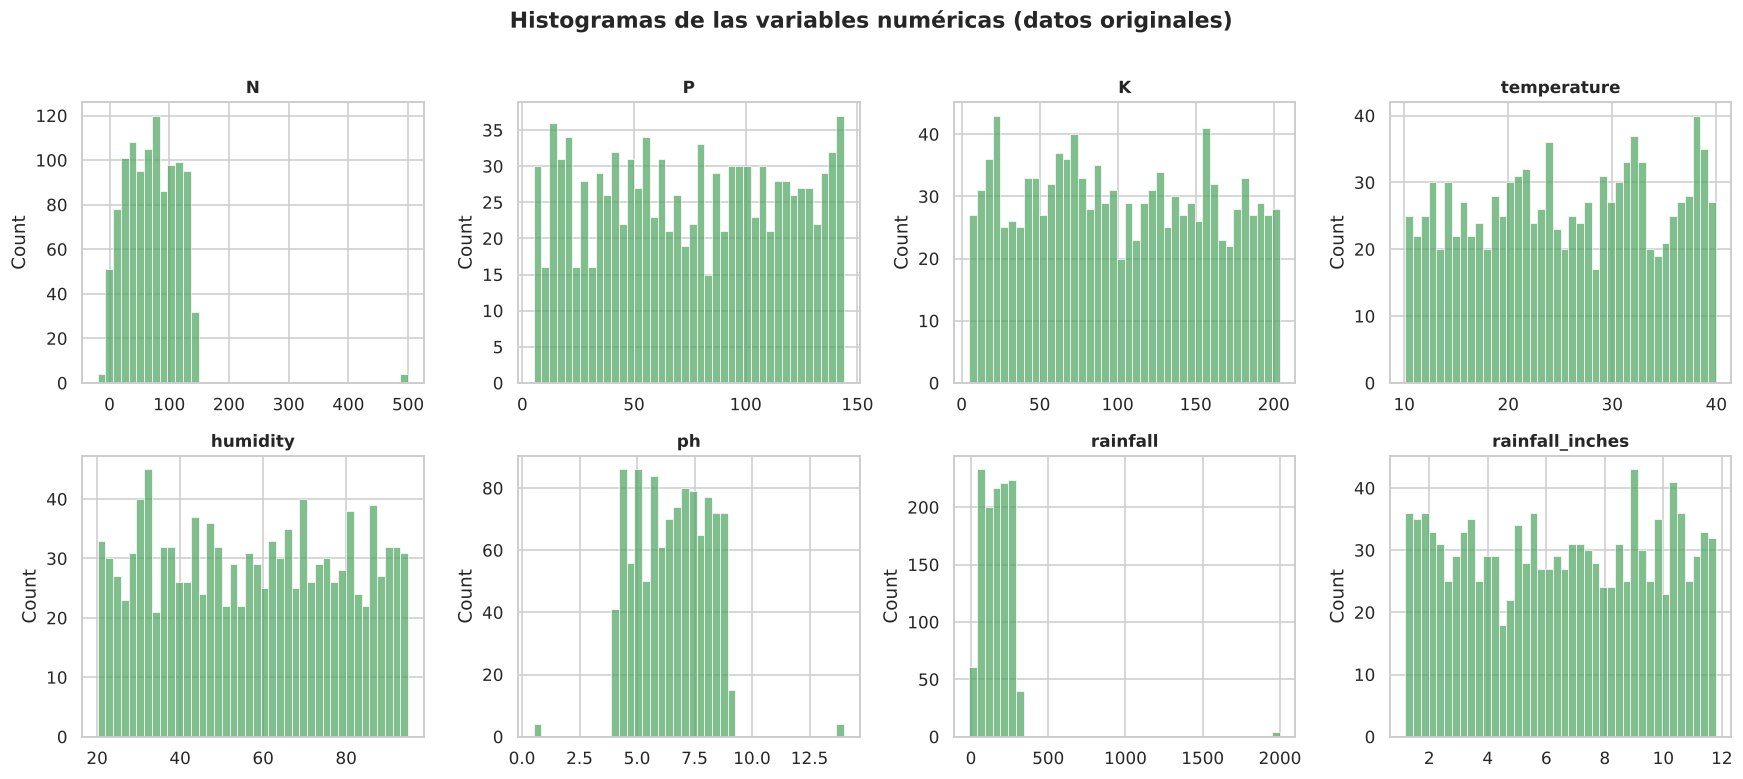

In [8]:
num_pred = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), num_pred + ["rainfall_inches"]):
    sns.histplot(df_raw[col].dropna(), bins=40, ax=ax, color="#55A868")
    ax.set(title=col, xlabel="")
plt.suptitle("Histogramas de las variables numéricas (datos originales)", y=1.01, fontweight="bold")
plt.tight_layout(); guardar_fig("02_histogramas_numericas"); plt.show()

Casi todas las variables se reparten de forma bastante pareja a lo largo de su rango: `P`, `K`, `temperature`, `humidity` y `rainfall_inches` se parecen a una uniforme, `N` va de 0 a unos 140 y `ph` se concentra entre 4 y 9. Lo que llama la atención son los puntos sueltos muy lejos del resto: un grupo pequeño de `N` en 500, de `ph` en 0,5 y en 14, y de `rainfall` en 2000 (más algunos negativos que casi no se ven). Esos valores aplastan los histogramas de `N` y `rainfall` contra un lado.

Las escalas también son muy diferentes (de 0–14 en `ph` a cientos en `rainfall`), lo que justifica estandarizar más adelante.

### 3.3 Valores faltantes

Interesa saber cuántos faltan, si se concentran en algunas filas y, sobre todo, si el hecho de faltar tiene relación con el rendimiento. Si faltar no dice nada sobre el objetivo, imputar es razonable.

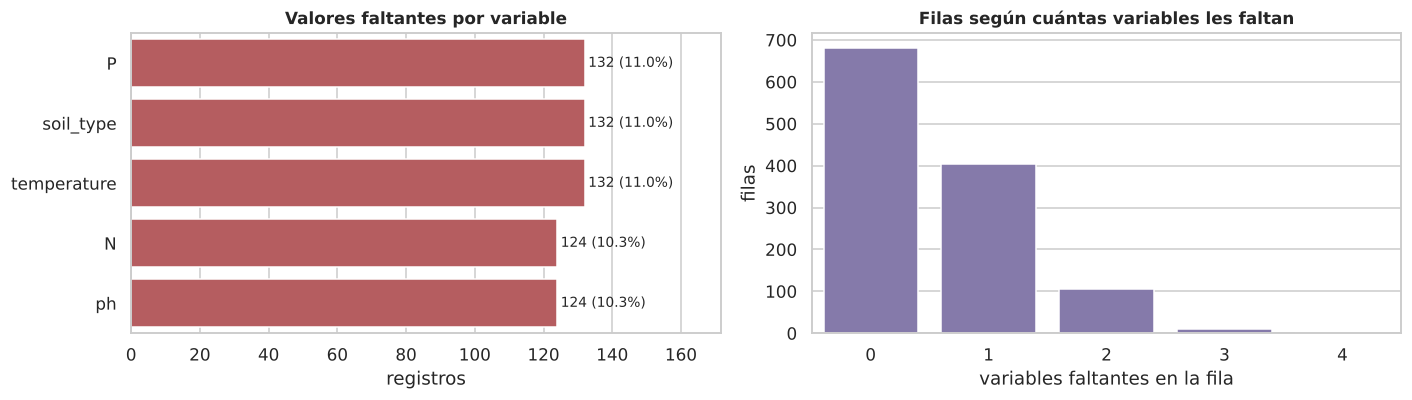

,rend_medio_si_falta,rend_medio_si_no_falta,p_valor
variable,,,
P,3.860,3.877,0.960
soil_type,3.851,3.878,0.750
temperature,3.841,3.879,0.817
N,3.833,3.880,0.573
ph,3.915,3.871,0.385


In [9]:
cols_nulos = nulos.index.tolist()
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
sns.barplot(x=nulos["nulos"], y=nulos.index, ax=ax[0], color="#C44E52")
for i, v in enumerate(nulos["nulos"]):
    ax[0].text(v + 1, i, f"{v} ({nulos['porcentaje'].iloc[i]:.1f}%)", va="center", fontsize=9)
ax[0].set(title="Valores faltantes por variable", xlabel="registros", ylabel="")
ax[0].set_xlim(0, nulos["nulos"].max() * 1.3)

n_por_fila = df_raw[cols_nulos].isna().sum(axis=1).value_counts().sort_index()
sns.barplot(x=n_por_fila.index, y=n_por_fila.values, ax=ax[1], color="#8172B2")
ax[1].set(title="Filas según cuántas variables les faltan", xlabel="variables faltantes en la fila", ylabel="filas")
plt.tight_layout(); guardar_fig("03_valores_faltantes"); plt.show()

# ¿Depende el rendimiento de si el dato falta o no? (Mann-Whitney)
filas = []
for c in cols_nulos:
    falta = df_raw[c].isna()
    u = stats.mannwhitneyu(y_raw[falta], y_raw[~falta])
    filas.append({"variable": c, "rend_medio_si_falta": y_raw[falta].mean(),
                  "rend_medio_si_no_falta": y_raw[~falta].mean(), "p_valor": u.pvalue})
pd.DataFrame(filas).set_index("variable")

La prueba de Mann-Whitney compara el rendimiento de las parcelas a las que les falta el dato con el de las que lo tienen, y no encuentra diferencias en ninguna de las cinco variables (p entre 0,39 y 0,96). En otras palabras, que un dato falte no dice nada sobre el rendimiento, lo cual es compatible con faltantes al azar. Eso hace razonable imputar sin que la imputación introduzca un sesgo evidente.

Además, cada columna pierde apenas un 10–11 %, pero al sumarlas el 43 % de las filas queda afectado. Eliminar esas filas habría sido un desperdicio enorme de información.

## 4–5. Análisis de calidad de datos

Esta parte es la que justifica todo lo que se hace en la limpieza. Se revisa cada punto por separado y solo al final, en la sección 6, se toman decisiones.

### 5.1 Valores físicamente imposibles

Se define para cada variable una regla de validez física y se cuentan los registros que la violan. Todavía no se elimina nada.

In [10]:
reglas = {
    "N negativo": df_raw["N"] < 0,
    "P negativo": df_raw["P"] < 0,
    "K negativo": df_raw["K"] < 0,
    "temperature fuera de -50 a 60 °C": (df_raw["temperature"] < -50) | (df_raw["temperature"] > 60),
    "humidity fuera de 0 a 100 %": (df_raw["humidity"] < 0) | (df_raw["humidity"] > 100),
    "ph fuera de la escala 0 a 14": (df_raw["ph"] < 0) | (df_raw["ph"] > 14),
    "rainfall negativa": df_raw["rainfall"] < 0,
    "rainfall_inches negativa": df_raw["rainfall_inches"] < 0,
    "yield_ton_ha menor o igual a 0": df_raw["yield_ton_ha"] <= 0,
}
imposibles = pd.Series({k: int(v.sum()) for k, v in reglas.items()}, name="registros que violan la regla")
imposibles.to_frame()

,registros que violan la regla
N negativo,4
P negativo,0
K negativo,0
temperature fuera de -50 a 60 °C,0
humidity fuera de 0 a 100 %,0
ph fuera de la escala 0 a 14,0
rainfall negativa,4
rainfall_inches negativa,0
yield_ton_ha menor o igual a 0,0


Solo dos reglas se rompen, y las dos son claras: hay 4 filas con `N` negativo y 4 con `rainfall` negativa. Un contenido de nitrógeno no puede ser menor que cero ni la lluvia acumulada tampoco, así que son errores de captura, no condiciones agrícolas extremas.

Ojo con lo que esta tabla **no** ve: `ph = 0,5` y `ph = 14` caen dentro de la escala nominal de 0 a 14, por eso no aparecen aquí. Son sospechosos por otra razón, y se analizan como extremos a continuación.

### 5.2 Valores extremos (outliers)

Se usan dos criterios distintos para no depender de uno solo: la regla de Tukey (IQR, fuera de Q1 − 1.5·IQR y Q3 + 1.5·IQR) y el z-score modificado basado en la mediana (|Mz| > 3.5), que es más robusto cuando hay valores muy grandes. Se aplican a todas las numéricas, aunque el foco está en `N`, `ph` y `rainfall`.

In [11]:
def fences_iqr(s):
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

def z_modificado(s):
    mediana = s.median(); mad = (s - mediana).abs().median()
    return 0.6745 * (s - mediana) / mad

filas = []
for c in num_pred + ["yield_ton_ha"]:
    s = df_raw[c].dropna(); lo, hi = fences_iqr(s)
    filas.append({"variable": c, "limite_inf_IQR": lo, "limite_sup_IQR": hi,
                  "fuera_IQR": int(((s < lo) | (s > hi)).sum()),
                  "fuera_z_modificado": int((z_modificado(s).abs() > 3.5).sum()),
                  "min": s.min(), "max": s.max()})
tab_outliers = pd.DataFrame(filas).set_index("variable")
display(tab_outliers)

print("\nValores que quedan fuera de los límites IQR y cuántas veces aparece cada uno:")
for c in ["N", "ph", "rainfall"]:
    lo, hi = fences_iqr(df_raw[c].dropna())
    fuera = df_raw.loc[(df_raw[c] < lo) | (df_raw[c] > hi), c]
    print(f"  {c:9s} -> {fuera.value_counts().sort_index().to_dict()}")

,limite_inf_IQR,limite_sup_IQR,fuera_IQR,fuera_z_modificado,min,max
variable,,,,,,
N,-68.500,207.500,4,4,-20.000,500.000
P,-66.500,217.500,0,0,5.000,144.000
K,-95.875,301.125,0,0,5.000,204.000
temperature,-3.181,54.223,0,0,10.110,39.954
humidity,-19.531,133.359,0,0,20.118,94.924
ph,1.302,11.682,8,4,0.500,14.000
rainfall,-119.273,445.580,4,4,-10.000,"2,000.000"
yield_ton_ha,1.724,6.017,3,0,1.268,6.021



Valores que quedan fuera de los límites IQR y cuántas veces aparece cada uno:
  N         -> {500.0: 4}
  ph        -> {0.5: 4, 14.0: 4}
  rainfall  -> {2000.0: 4}


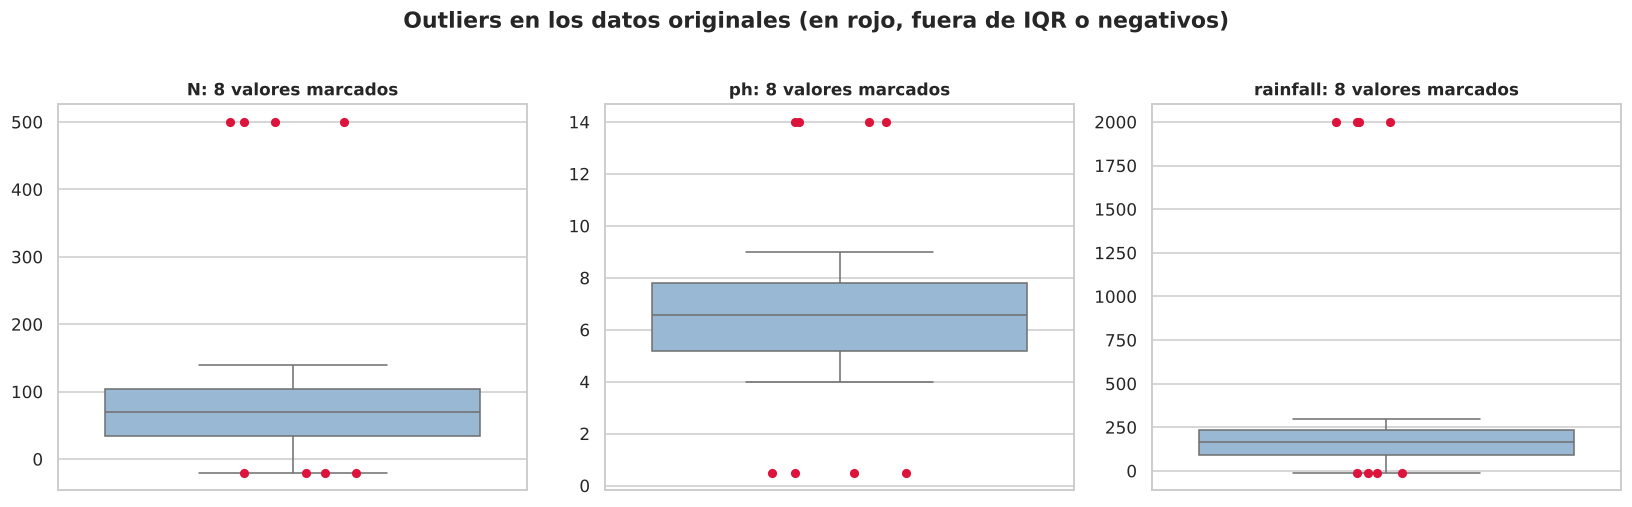

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, c in zip(axes, ["N", "ph", "rainfall"]):
    lo, hi = fences_iqr(df_raw[c].dropna())
    s = df_raw[c]
    marcados = s[(s < lo) | (s > hi) | (s < 0)]
    sns.boxplot(y=s, ax=ax, color="#8FB8DE", fliersize=0)
    sns.stripplot(y=marcados, ax=ax, color="crimson", size=6, jitter=0.15)
    ax.set(title=f"{c}: {len(marcados)} valores marcados", ylabel="")
plt.suptitle("Outliers en los datos originales (en rojo, fuera de IQR o negativos)", y=1.02, fontweight="bold")
plt.tight_layout(); guardar_fig("04_outliers_originales"); plt.show()

Hay tres cosas que sorprenden.

**Primero, los valores extremos no son variación natural.** Los que marca el IQR son `N = 500` (4 filas), `ph = 0,5` y `ph = 14` (4 filas cada uno) y `rainfall = 2000` (4 filas). Siempre el mismo número repetido exactamente cuatro veces. Una medición real de suelo no produce eso; es la huella de un valor de relleno o de un error de captura. El z-score modificado coincide con el IQR en `N` y `rainfall` y en `ph` solo marca 4 de los 8 (los demás quedan dentro de su umbral).

**Segundo, el IQR por sí solo se queda corto.** Los límites de `N` son −68,5 y 207,5, de modo que el `N = −20` pasa inadvertido, y lo mismo ocurre con `rainfall = −10` (límite inferior −119). Los negativos solo se detectan con la regla física de la sección anterior. Un método estadístico no sustituye al conocimiento del dominio.

**Tercero, un valor grande no es necesariamente un error.** 2000 mm de lluvia anual no es imposible en un clima tropical. Lo que de verdad delata a esas filas viene en la siguiente comprobación.

En `yield_ton_ha` el IQR marca 3 puntos, pero son colas razonables de la distribución, no los toco.

### 5.3 Redundancia: `rainfall` frente a `rainfall_inches`

Si `rainfall_inches` es solo `rainfall` expresada en otra unidad, deberían cumplir `rainfall_inches = rainfall / 25.4` en todas las filas. Se comprueba fila por fila en lugar de fiarse del diccionario.

In [13]:
conversion = df_raw["rainfall"] / 25.4
dif = (conversion - df_raw["rainfall_inches"]).abs()
coinciden = dif < 0.01

print(f"Filas donde rainfall/25.4 coincide con rainfall_inches: {coinciden.sum()} de {len(df_raw)}")
print(f"Diferencia máxima en esas filas: {dif[coinciden].max():.2e}")
print(f"Correlación (Pearson) usando todas las filas : {df_raw['rainfall'].corr(df_raw['rainfall_inches']):.3f}")
print(f"Correlación (Pearson) sin las filas que no coinciden: {df_raw.loc[coinciden, 'rainfall'].corr(df_raw.loc[coinciden, 'rainfall_inches']):.3f}")

incoherentes = df_raw.loc[~coinciden, ["RecordID", "rainfall", "rainfall_inches"]].assign(mm_segun_pulgadas=lambda d: d["rainfall_inches"] * 25.4)
incoherentes

Filas donde rainfall/25.4 coincide con rainfall_inches: 1192 de 1200
Diferencia máxima en esas filas: 5.33e-15
Correlación (Pearson) usando todas las filas : 0.602
Correlación (Pearson) sin las filas que no coinciden: 1.000


,RecordID,rainfall,rainfall_inches,mm_segun_pulgadas
50,REC00051,"2,000.000",5.048,128.217
462,REC00463,"2,000.000",3.190,81.029
509,REC00510,-10.000,5.186,131.714
541,REC00542,"2,000.000",10.533,267.541
667,REC00668,-10.000,9.488,240.985
1050,REC01051,"2,000.000",8.097,205.669
1067,REC01068,-10.000,2.925,74.299
1119,REC01120,-10.000,6.291,159.800


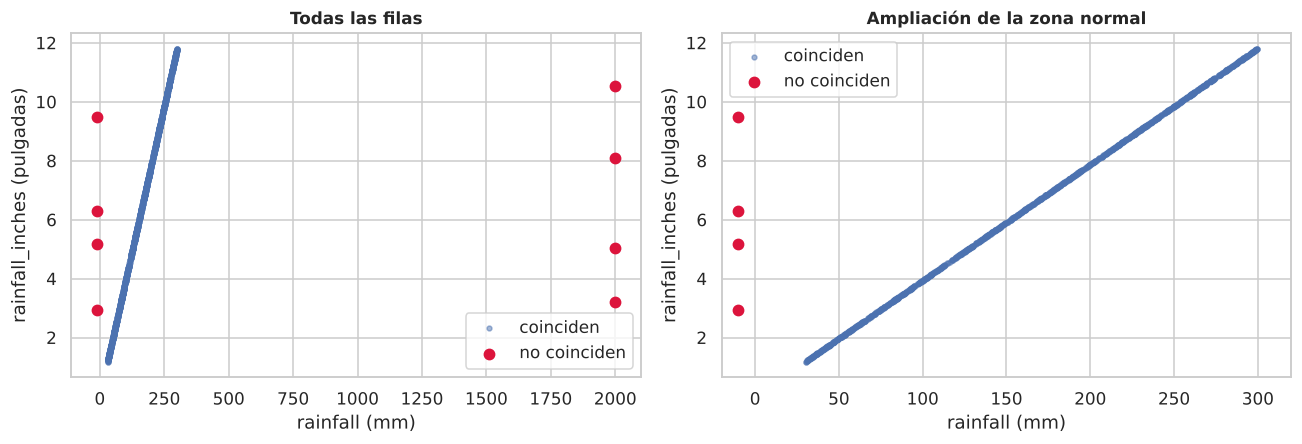

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for a, zoom in zip(ax, [False, True]):
    a.scatter(df_raw.loc[coinciden, "rainfall"], df_raw.loc[coinciden, "rainfall_inches"], s=10, alpha=0.5, label="coinciden")
    a.scatter(df_raw.loc[~coinciden, "rainfall"], df_raw.loc[~coinciden, "rainfall_inches"], s=45, color="crimson", label="no coinciden")
    a.set(xlabel="rainfall (mm)", ylabel="rainfall_inches (pulgadas)")
    if zoom:
        a.set_xlim(-20, 320); a.set_title("Ampliación de la zona normal")
    else:
        a.set_title("Todas las filas")
    a.legend()
plt.tight_layout(); guardar_fig("05_rainfall_vs_pulgadas"); plt.show()

`rainfall_inches` es `rainfall / 25,4` en 1.192 de las 1.200 filas, con una diferencia máxima del orden de 1e-15: es la misma medida expresada en otra unidad. Las 8 filas que no coinciden son exactamente las 8 con `rainfall` en −10 o en 2000. Como la columna en pulgadas sí es coherente en esas filas (equivale a entre 74 y 268 mm, valores totalmente normales), lo que está dañado es `rainfall` y no `rainfall_inches`. La correlación pasa de 0,60 con todas las filas a 1,000 sin esas 8.

Este es el argumento sólido para tratar la lluvia: no se descarta el 2000 por ser grande, sino porque otra medición de la misma parcela lo contradice. Y como la columna en pulgadas guarda el valor correcto, se puede **recuperar** el dato en lugar de perder la fila o imputarla.

### 5.4 Variables constantes o casi constantes

Una variable casi constante aporta poco y puede meter ruido. Antes de descartar `Country` se mira cuánto varía y si el rendimiento cambia entre sus categorías.

In [15]:
print(df_raw["Country"].value_counts(normalize=True).mul(100).round(1).to_string())
print("\nRendimiento medio por país:")
print(df_raw.groupby("Country")["yield_ton_ha"].agg(["count", "mean", "std"]).round(3).to_string())
print("\nVariables con un único valor:", [c for c in df_raw.columns if df_raw[c].nunique(dropna=True) <= 1] or "ninguna")

Country
Colombia   96.000
Other       4.000

Rendimiento medio por país:
          count  mean   std
Country                    
Colombia   1152 3.875 0.769
Other        48 3.882 0.834

Variables con un único valor: ninguna


### 5.5 Identificadores y variables sin valor predictivo aparente

Aquí se contrasta con datos lo que el diccionario sugiere. Para cada variable candidata a descartarse se mide si hay relación con el rendimiento:

- **Categóricas** (`ZodiacSign`, `FavoriteColor`, `Hobby`, `Country`, `FarmID`, y también `soil_type` y `label` para compararlas): prueba de Kruskal-Wallis y eta² (proporción de la varianza del rendimiento que explican las categorías). Como eta² siempre sale algo positivo por azar y más cuando hay muchas categorías, se muestra también el valor que se esperaría solo por azar, `(k − 1)/(n − 1)`.
- **`Phone`**: correlación de Spearman con el rendimiento.
- **`FarmID`**: además, una prueba de permutación. Cada finca tiene unos 6 registros; si hubiera «fincas buenas» y «fincas malas», la varianza entre las medias por finca sería mayor que la que sale al barajar el rendimiento al azar.

In [16]:
y_s = df_raw["yield_ton_ha"]

def prueba_categorica(col):
    d = df_raw[[col, "yield_ton_ha"]].dropna()
    grupos = [g["yield_ton_ha"].values for _, g in d.groupby(col)]
    k, n = len(grupos), len(d)
    H, p = stats.kruskal(*grupos)
    sst = ((d["yield_ton_ha"] - d["yield_ton_ha"].mean()) ** 2).sum()
    ssb = sum(len(g) * (g.mean() - d["yield_ton_ha"].mean()) ** 2 for g in grupos)
    return {"variable": col, "niveles": k, "n": n, "p_valor_kruskal": p,
            "eta2": ssb / sst, "eta2_esperado_por_azar": (k - 1) / (n - 1)}

evidencia = pd.DataFrame([prueba_categorica(c) for c in
                          ["ZodiacSign", "FavoriteColor", "Hobby", "Country", "FarmID", "soil_type", "label"]]).set_index("variable")
evidencia["eta2_sobre_azar"] = evidencia["eta2"] - evidencia["eta2_esperado_por_azar"]
evidencia["p_ajustado_bonferroni"] = (evidencia["p_valor_kruskal"] * len(evidencia)).clip(upper=1)  # 7 pruebas
display(evidencia)

rho_phone, p_phone = stats.spearmanr(df_raw["Phone"], y_s)
print(f"Phone vs rendimiento: Spearman rho = {rho_phone:.3f} (p = {p_phone:.3f})")
print(f"FullName: {df_raw['FullName'].nunique()} nombres distintos en {len(df_raw)} filas (dato personal)")
print(f"RecordID: {df_raw['RecordID'].nunique()} valores únicos en {len(df_raw)} filas (identificador puro)")

,niveles,n,p_valor_kruskal,eta2,eta2_esperado_por_azar,eta2_sobre_azar,p_ajustado_bonferroni
variable,,,,,,,
ZodiacSign,12,1200,0.517,0.008,0.009,-0.001,1.000
FavoriteColor,10,1200,0.024,0.014,0.008,0.007,0.165
Hobby,10,1200,0.575,0.006,0.008,-0.001,1.000
Country,2,1200,0.810,0.000,0.001,-0.001,1.000
FarmID,199,1200,0.308,0.171,0.165,0.006,1.000
soil_type,22,1068,0.974,0.011,0.020,-0.009,1.000
label,23,1200,0.497,0.017,0.018,-0.001,1.000


Phone vs rendimiento: Spearman rho = -0.037 (p = 0.195)
FullName: 378 nombres distintos en 1200 filas (dato personal)
RecordID: 1200 valores únicos en 1200 filas (identificador puro)


In [17]:
# Prueba de permutación para FarmID
rng = np.random.default_rng(SEED)
codigos = pd.factorize(df_raw["FarmID"])[0]
conteo = np.bincount(codigos)

def varianza_medias_por_finca(valores):
    return (np.bincount(codigos, weights=valores) / conteo).var(ddof=1)

obs = varianza_medias_por_finca(y_s.values)
sim = np.array([varianza_medias_por_finca(rng.permutation(y_s.values)) for _ in range(5000)])
p_perm_farm = (np.sum(sim >= obs) + 1) / (len(sim) + 1)

print(f"Fincas distintas: {len(conteo)} | registros por finca: media {conteo.mean():.1f}, mín {conteo.min()}, máx {conteo.max()}")
print(f"Varianza entre medias de finca observada: {obs:.4f}")
print(f"Varianza esperada si el rendimiento no dependiera de la finca (media de 5000 permutaciones): {sim.mean():.4f}")
print(f"p-valor de la prueba de permutación: {p_perm_farm:.3f}")

Fincas distintas: 199 | registros por finca: media 6.0, mín 1, máx 12
Varianza entre medias de finca observada: 0.1247
Varianza esperada si el rendimiento no dependiera de la finca (media de 5000 permutaciones): 0.1217
p-valor de la prueba de permutación: 0.395


Ninguna de las variables candidatas a descartarse muestra relación con el rendimiento:

- `ZodiacSign`, `Hobby`, `Country` y `label` tienen p-valores entre 0,50 y 0,81 y eta² igual o por debajo de lo que se esperaría por puro azar.
- `FavoriteColor` es la única con p = 0,024. Es un caso para pensar: con siete pruebas hechas a la vez es esperable que alguna salga por debajo de 0,05 por casualidad. Con la corrección de Bonferroni el p-valor ajustado es 0,165, y su eta² supera al azar en solo 0,007, menos de un 1 % de la varianza. No lo considero una señal real, y tampoco tendría ninguna explicación agronómica.
- `Phone` tiene una correlación de Spearman de −0,04 (p = 0,195).
- `FarmID` merece un comentario aparte porque su eta² (0,171) parece alto. Pero con 199 fincas de unos 6 registros cada una, el azar por sí solo produce 0,165. La prueba de permutación lo confirma: la varianza entre medias de finca es 0,1247 y barajando el rendimiento sale 0,1217 en promedio (p = 0,395). No existe un «efecto finca».
- `Country`: la media es prácticamente idéntica en Colombia (3,875) y en «Other» (3,882).
- `label`: el cultivo recomendado no cambia el rendimiento medio (p = 0,497).

Todo esto respalda las decisiones de eliminar esas columnas con datos propios, no solo por lo que dice el diccionario.

### 5.6 `soil_type`: la única categórica candidata

Tiene 22 niveles, algunos con nombre de suelo real (`Loamy`, `Clay`, `Sandy`…) y otros genéricos (`Type0`…`Type14`). Es de cardinalidad media, no tan alta como un identificador. El gráfico compara el rendimiento medio de cada nivel con su intervalo de confianza para ver si de verdad se separan unos de otros.

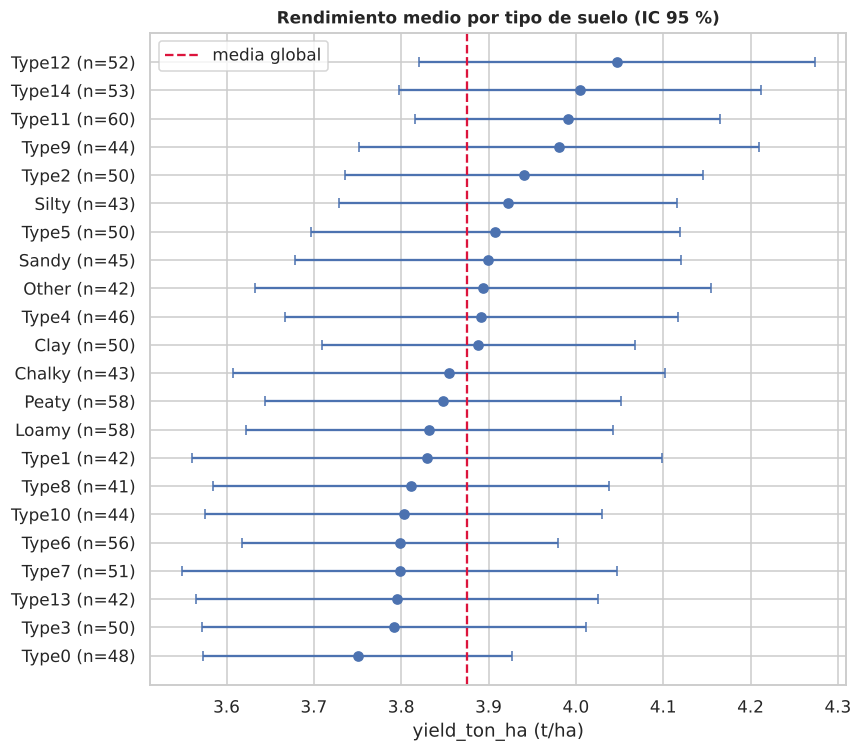

Niveles cuyo IC 95 % no contiene la media global: 0 de 22


In [18]:
g = (df_raw.dropna(subset=["soil_type"]).groupby("soil_type")["yield_ton_ha"]
     .agg(media="mean", sem=lambda v: v.std(ddof=1) / np.sqrt(len(v)), n="count").sort_values("media"))

fig, ax = plt.subplots(figsize=(8, 7))
ax.errorbar(g["media"], range(len(g)), xerr=1.96 * g["sem"], fmt="o", capsize=3, color="#4C72B0")
ax.axvline(df_raw["yield_ton_ha"].mean(), color="crimson", ls="--", label="media global")
ax.set_yticks(range(len(g))); ax.set_yticklabels([f"{i} (n={n})" for i, n in zip(g.index, g["n"])])
ax.set(title="Rendimiento medio por tipo de suelo (IC 95 %)", xlabel="yield_ton_ha (t/ha)")
ax.legend(); plt.tight_layout(); guardar_fig("06_rendimiento_por_soil_type"); plt.show()
print(f"Niveles cuyo IC 95 % no contiene la media global: {(((g['media'] - 1.96 * g['sem']) > df_raw['yield_ton_ha'].mean()) | ((g['media'] + 1.96 * g['sem']) < df_raw['yield_ton_ha'].mean())).sum()} de {len(g)}")

Con 22 niveles y entre 41 y 60 filas por nivel, `soil_type` tiene una cardinalidad media, manejable con *one-hot*: serían 22 columnas (más una de «Desconocido» para los faltantes), frente a 960 filas de entrenamiento. No es el problema de alta cardinalidad de un identificador.

Lo importante es lo que muestra el gráfico: los intervalos de confianza de los 22 niveles se solapan con la media global, ninguno (0 de 22) queda fuera de ella. La prueba de Kruskal-Wallis lo confirma (p = 0,974) y eta² está por debajo de lo esperable por azar. Es decir, a primera vista el tipo de suelo no parece influir en el rendimiento. Se mantiene como candidata, pero esa sospecha se comprueba con validación cruzada en la sección 9.1.

### 5.7 Escalas y correlaciones

Las variables numéricas viven en rangos muy distintos. Esto no importa para los árboles, pero sí para la regresión regularizada, KNN y SVR, que dependen de distancias o penalizan coeficientes. La correlación se calcula con Spearman, que no se deja arrastrar por los valores extremos que aún no se han tratado.

,min,median,max,std,rango
N,-20.000,70.000,500.000,47.892,520.000
P,5.000,75.000,144.000,40.988,139.000
K,5.000,99.000,204.000,57.609,199.000
temperature,10.110,25.539,39.954,8.649,29.843
humidity,20.118,57.658,94.924,21.779,74.806
ph,0.500,6.575,14.000,1.557,13.500
rainfall,-10.000,165.907,"2,000.000",132.828,"2,010.000"


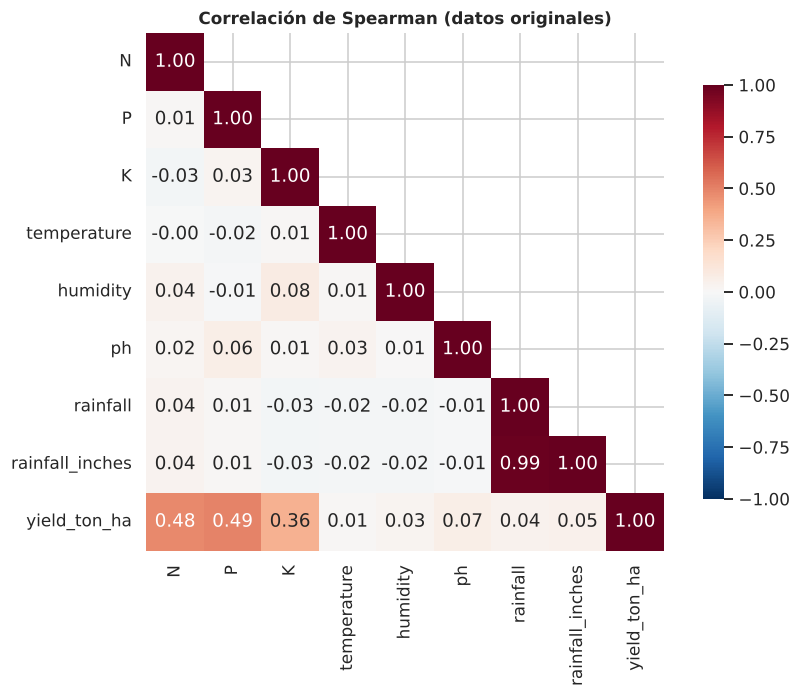

Correlación de Spearman con el rendimiento:


,rho
P,0.493
N,0.480
K,0.357
ph,0.070
rainfall_inches,0.048
rainfall,0.043
humidity,0.028
temperature,0.014


In [19]:
escalas = df_raw[num_pred].agg(["min", "median", "max", "std"]).T
escalas["rango"] = escalas["max"] - escalas["min"]
display(escalas)

cols_corr = num_pred + ["rainfall_inches", "yield_ton_ha"]
corr = df_raw[cols_corr].corr(method="spearman")
fig, ax = plt.subplots(figsize=(8.5, 6.5))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool), k=1), annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Correlación de Spearman (datos originales)")
plt.tight_layout(); guardar_fig("07_correlaciones"); plt.show()

print("Correlación de Spearman con el rendimiento:")
corr["yield_ton_ha"].drop("yield_ton_ha").sort_values(ascending=False).to_frame("rho")

La matriz cuenta una historia simple. Con el rendimiento correlacionan `P` (0,49), `N` (0,48) y `K` (0,36). Todo lo demás está entre 0,01 y 0,07, es decir, nada. Entre las propias predictoras tampoco hay relaciones (todas por debajo de 0,08 en valor absoluto), con una única excepción: `rainfall` y `rainfall_inches` (0,99), lo cual confirma la redundancia vista antes.

Dos consecuencias. Que las predictoras sean casi independientes entre sí quita el problema de multicolinealidad y, de paso, hace pensar que imputar un dato apoyándose en las otras variables (KNN, imputación iterativa) no va a aportar mucho. Y como solo tres variables se relacionan con el objetivo, hay que esperar un techo de rendimiento predictivo modesto.

### 5.8 Riesgo de *data leakage*

Se revisa variable por variable si usarla en el modelo sería hacer trampa, es decir, si contiene información que en producción no se tendría o que se deriva del propio objetivo.

In [20]:
leakage = pd.DataFrame([
    ("yield_ton_ha", "Es el objetivo. Nunca puede estar en X.", "Excluida de X"),
    ("label", "Cultivo recomendado: es un resultado del mismo proceso agronómico, no una condición del suelo o del clima. Además, para usarlo habría que saber el cultivo antes de predecir su rendimiento.", "Excluida de X"),
    ("rainfall_inches", "No contiene información del objetivo, pero es la misma medida que rainfall. Mantener las dos duplica información y crea colinealidad perfecta.", "Se usa solo para reparar rainfall y luego se elimina"),
    ("FarmID", "Identificador. Un modelo flexible podría memorizar fincas en lugar de aprender condiciones del suelo, y no generaliza a fincas nuevas.", "Excluida de X"),
    ("RecordID, FullName, Phone", "Identificadores y datos personales sin relación causal con el rendimiento.", "Excluidas de X"),
    ("Imputación y escalado", "Si se calculan medianas o medias con todo el dataset, el conjunto de prueba influye en el entrenamiento.", "Se aprenden solo con train, dentro de un Pipeline"),
], columns=["elemento", "riesgo", "decisión"])
leakage.style.set_properties(**{"text-align": "left", "white-space": "pre-wrap"}).hide(axis="index")

elemento,riesgo,decisión
yield_ton_ha,Es el objetivo. Nunca puede estar en X.,Excluida de X
label,"Cultivo recomendado: es un resultado del mismo proceso agronómico, no una condición del suelo o del clima. Además, para usarlo habría que saber el cultivo antes de predecir su rendimiento.",Excluida de X
rainfall_inches,"No contiene información del objetivo, pero es la misma medida que rainfall. Mantener las dos duplica información y crea colinealidad perfecta.",Se usa solo para reparar rainfall y luego se elimina
FarmID,"Identificador. Un modelo flexible podría memorizar fincas en lugar de aprender condiciones del suelo, y no generaliza a fincas nuevas.",Excluida de X
"RecordID, FullName, Phone",Identificadores y datos personales sin relación causal con el rendimiento.,Excluidas de X
Imputación y escalado,"Si se calculan medianas o medias con todo el dataset, el conjunto de prueba influye en el entrenamiento.","Se aprenden solo con train, dentro de un Pipeline"


Revisando la tabla, la única forma de *leakage* que quedaba abierta era la del procesamiento, y se cierra construyendo todo dentro de un `Pipeline`. Tampoco hay ninguna variable con una correlación sospechosamente alta con el objetivo (la mayor es 0,49), que sería la señal típica de que algo se «filtró».

## 6. Limpieza de datos (ETL)

### 6.1 Decisiones, con la evidencia que las respalda

Antes de borrar nada se junta en una tabla lo que mostró el análisis anterior. Cada columna se elimina porque los datos lo apoyan, no porque el diccionario lo diga.

In [21]:
def p_fmt(p):
    return "<0.001" if p < 0.001 else f"{p:.3f}"

ev = evidencia
decisiones = pd.DataFrame([
    ("RecordID", "Eliminar", f"{df_raw['RecordID'].nunique()} valores únicos en {len(df_raw)} filas: identificador puro."),
    ("FullName", "Eliminar", f"{df_raw['FullName'].nunique()} nombres repetidos al azar; es un dato personal sin relación con el cultivo."),
    ("Phone", "Eliminar", f"Número telefónico (dato personal). Spearman con el rendimiento = {rho_phone:.3f} (p = {p_fmt(p_phone)})."),
    ("ZodiacSign", "Eliminar", f"Kruskal p = {p_fmt(ev.loc['ZodiacSign','p_valor_kruskal'])} (ajustado por 7 pruebas: {p_fmt(ev.loc['ZodiacSign','p_ajustado_bonferroni'])}); eta² = {ev.loc['ZodiacSign','eta2']:.3f} (azar esperado {ev.loc['ZodiacSign','eta2_esperado_por_azar']:.3f})."),
    ("FavoriteColor", "Eliminar", f"Kruskal p = {p_fmt(ev.loc['FavoriteColor','p_valor_kruskal'])} (ajustado por 7 pruebas: {p_fmt(ev.loc['FavoriteColor','p_ajustado_bonferroni'])}); eta² = {ev.loc['FavoriteColor','eta2']:.3f} (azar esperado {ev.loc['FavoriteColor','eta2_esperado_por_azar']:.3f})."),
    ("Hobby", "Eliminar", f"Kruskal p = {p_fmt(ev.loc['Hobby','p_valor_kruskal'])} (ajustado por 7 pruebas: {p_fmt(ev.loc['Hobby','p_ajustado_bonferroni'])}); eta² = {ev.loc['Hobby','eta2']:.3f} (azar esperado {ev.loc['Hobby','eta2_esperado_por_azar']:.3f})."),
    ("FarmID", "Eliminar", f"Identificador de {ev.loc['FarmID','niveles']} fincas (~6 filas cada una). Permutación p = {p_fmt(p_perm_farm)}: no hay efecto de finca más allá del azar."),
    ("Country", "Eliminar", f"{df_raw['Country'].value_counts(normalize=True).iloc[0]:.0%} de las filas son del mismo país. Kruskal p = {p_fmt(ev.loc['Country','p_valor_kruskal'])}."),
    ("label", "Excluir de X", f"Kruskal p = {p_fmt(ev.loc['label','p_valor_kruskal'])}; eta² = {ev.loc['label','eta2']:.3f} (azar esperado {ev.loc['label','eta2_esperado_por_azar']:.3f}). Además queda fuera por diseño: no se usa para predecir el rendimiento."),
    ("rainfall_inches", "Usar y eliminar", "Se usa para reparar 8 valores inválidos de rainfall y después se elimina por redundancia."),
    ("soil_type", "Conservar", f"Sin relación univariada con el rendimiento (Kruskal p = {p_fmt(ev.loc['soil_type','p_valor_kruskal'])}; eta² por debajo del azar). Se mantiene como candidata porque es parte del planteamiento (y podría interactuar con otras variables) y su aporte real se mide con validación cruzada en 9.1."),
    ("N, P, K, temperature, humidity, ph, rainfall", "Conservar", "Variables ambientales y de suelo del planteamiento. Se tratan nulos y valores inválidos."),
], columns=["variable", "decisión", "evidencia"])
decisiones.style.set_properties(**{"text-align": "left", "white-space": "pre-wrap"}).hide(axis="index")

variable,decisión,evidencia
RecordID,Eliminar,1200 valores únicos en 1200 filas: identificador puro.
FullName,Eliminar,378 nombres repetidos al azar; es un dato personal sin relación con el cultivo.
Phone,Eliminar,Número telefónico (dato personal). Spearman con el rendimiento = -0.037 (p = 0.195).
ZodiacSign,Eliminar,Kruskal p = 0.517 (ajustado por 7 pruebas: 1.000); eta² = 0.008 (azar esperado 0.009).
FavoriteColor,Eliminar,Kruskal p = 0.024 (ajustado por 7 pruebas: 0.165); eta² = 0.014 (azar esperado 0.008).
Hobby,Eliminar,Kruskal p = 0.575 (ajustado por 7 pruebas: 1.000); eta² = 0.006 (azar esperado 0.008).
FarmID,Eliminar,Identificador de 199 fincas (~6 filas cada una). Permutación p = 0.395: no hay efecto de finca más allá del azar.
Country,Eliminar,96% de las filas son del mismo país. Kruskal p = 0.810.
label,Excluir de X,Kruskal p = 0.497; eta² = 0.017 (azar esperado 0.018). Además queda fuera por diseño: no se usa para predecir el rendimiento.
rainfall_inches,Usar y eliminar,Se usa para reparar 8 valores inválidos de rainfall y después se elimina por redundancia.


De las 19 columnas originales se descartan 10 (nueve eliminadas por falta de valor predictivo o por ser identificadores, más `rainfall_inches` tras usarla) y quedan 9: las siete variables numéricas, `soil_type` y el objetivo.

Un detalle sobre `soil_type`: no tiene evidencia a favor y sin embargo no la elimino todavía. El motivo es que forma parte del planteamiento del problema, que la validación cruzada puede decir con más autoridad que una prueba univariada si aporta o no (podría actuar en combinación con otras variables), y que varios de los modelos pueden neutralizarla si no sirve.

### 6.2 Tratamiento de valores inválidos y extremos

La regla que se sigue en cada variable:

| Variable | Problema detectado | Tratamiento | Por qué |
|---|---|---|---|
| `rainfall` | −10 mm y 2000 mm, cada uno 4 veces | Se reconstruye como `rainfall_inches × 25.4` | La columna en pulgadas coincide con `rainfall/25.4` en el resto de filas. Así se conserva el registro y se recupera el valor real, sin inventar nada. |
| `N` | −20 (4 filas) y 500 (4 filas) | Se pasa a `NaN` | Un contenido negativo no existe. El 500 es 3.6 veces el máximo del resto de filas (140) y se repite idéntico. Quedan como faltantes para imputarse. |
| `ph` | 0.5 (4 filas) y 14 (4 filas) | Se pasa a `NaN` | Son los dos extremos de la escala, repetidos exactamente igual. Valores así en un suelo cultivable no son creíbles. |

**Sobre el momento de aplicarlo:** estas reglas no aprenden nada de la distribución de los datos (son límites físicos y una conversión de unidades), así que aplicarlas antes de dividir en train y test no produce *leakage*. La imputación sí aprende (medianas), y esa se hace dentro del pipeline, después de la división.

Los umbrales usados son: `N` entre 0 y 200 (por encima de todo lo observado en filas normales, 140, y por debajo del 500 repetido) y `ph` entre 3 y 10 (rango habitual de suelos cultivables).

In [22]:
RANGO_N, RANGO_PH = (0, 200), (3.0, 10.0)
TOL_MM = 0.5  # tolerancia entre rainfall y rainfall_inches * 25.4
COLS_DESCARTAR = ["RecordID", "FullName", "Phone", "ZodiacSign", "FavoriteColor", "Hobby",
                  "FarmID", "Country", "label", "rainfall_inches"]


def limpiar_datos(df):
    """ETL basado en reglas (físicas y de unidades). Devuelve el dataset limpio y un registro de cambios."""
    d = df.copy()
    registro = []

    # 1) rainfall: reconstruir desde pulgadas donde no es válida o no es coherente
    mm = d["rainfall_inches"] * 25.4
    mal = (d["rainfall"] < 0) | ((d["rainfall"] - mm).abs() > TOL_MM)
    for i in d.index[mal]:
        registro.append({"RecordID": d.at[i, "RecordID"], "variable": "rainfall", "valor_original": d.at[i, "rainfall"],
                         "tratamiento": f"reconstruida desde rainfall_inches ({mm[i]:.1f} mm)"})
    d.loc[mal, "rainfall"] = mm[mal]

    # 2) N y ph: valores fuera del rango plausible pasan a NaN (se imputan después, en el pipeline)
    for col, (lo, hi) in {"N": RANGO_N, "ph": RANGO_PH}.items():
        mal = (d[col] < lo) | (d[col] > hi)
        for i in d.index[mal]:
            registro.append({"RecordID": d.at[i, "RecordID"], "variable": col, "valor_original": d.at[i, col],
                             "tratamiento": "pasa a NaN (imputación posterior)"})
        d.loc[mal, col] = np.nan

    # 3) columnas sin valor predictivo, identificadores y redundantes
    d = d.drop(columns=COLS_DESCARTAR)
    return d, pd.DataFrame(registro)


df_clean, log_cambios = limpiar_datos(df_raw)
print(f"Registros de cambios: {len(log_cambios)} | filas distintas afectadas: {log_cambios['RecordID'].nunique()} de {len(df_raw)} ({log_cambios['RecordID'].nunique() / len(df_raw):.1%})")
log_cambios.groupby(["variable", "valor_original"]).size().rename("registros").to_frame()

Registros de cambios: 24 | filas distintas afectadas: 24 de 1200 (2.0%)


registros
variable valor_original           
N        -20.000                 4
         500.000                 4
ph       0.500                   4
         14.000                  4
rainfall -10.000                 4
         2,000.000               4

In [23]:
log_cambios.sort_values(["variable", "valor_original"]).reset_index(drop=True)

,RecordID,variable,valor_original,tratamiento
0,REC00090,N,-20.000,pasa a NaN (imputación posterior)
1,REC00131,N,-20.000,pasa a NaN (imputación posterior)
2,REC00270,N,-20.000,pasa a NaN (imputación posterior)
3,REC00746,N,-20.000,pasa a NaN (imputación posterior)
4,REC00034,N,500.000,pasa a NaN (imputación posterior)
5,REC00820,N,500.000,pasa a NaN (imputación posterior)
6,REC00938,N,500.000,pasa a NaN (imputación posterior)
7,REC01006,N,500.000,pasa a NaN (imputación posterior)
8,REC00049,ph,0.500,pasa a NaN (imputación posterior)
9,REC00389,ph,0.500,pasa a NaN (imputación posterior)


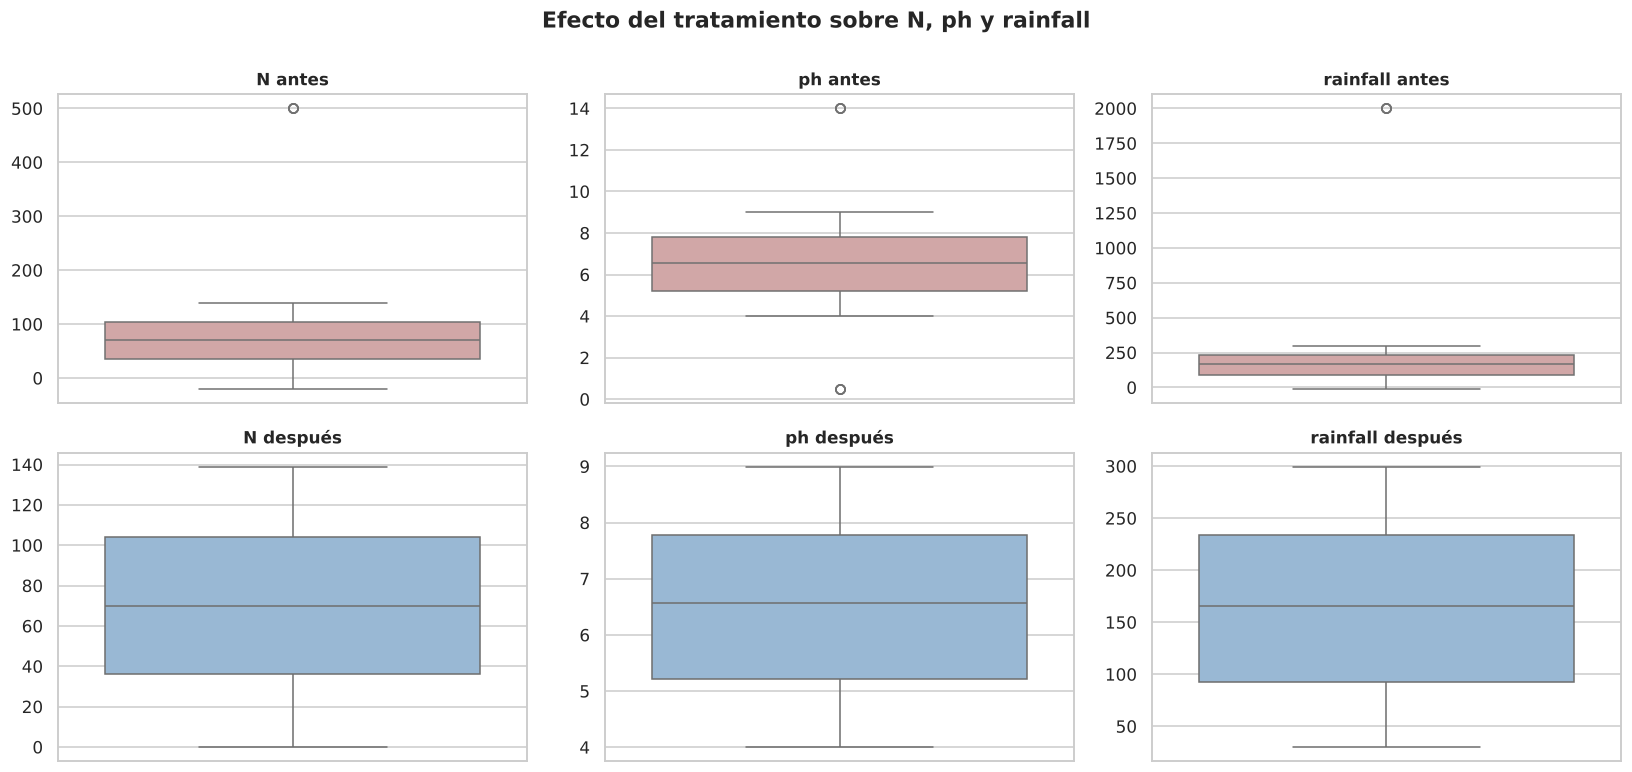

antes                           después                       
             min       max    mean     std     min     max    mean    std
N        -20.000   500.000  71.017  47.892   0.000 139.000  69.751 39.853
ph         0.500    14.000   6.530   1.557   4.004   8.998   6.524  1.448
rainfall -10.000 2,000.000 170.111 132.828  30.098 299.599 164.553 79.771

Nulos tras la limpieza:
N              132
P              132
temperature    132
ph             132
soil_type      132

Forma del dataset limpio: (1200, 9)


In [24]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for j, c in enumerate(["N", "ph", "rainfall"]):
    sns.boxplot(y=df_raw[c], ax=axes[0, j], color="#D8A0A0"); axes[0, j].set_title(f"{c} antes")
    sns.boxplot(y=df_clean[c], ax=axes[1, j], color="#8FB8DE"); axes[1, j].set_title(f"{c} después")
    for a in axes[:, j]: a.set_ylabel("")
plt.suptitle("Efecto del tratamiento sobre N, ph y rainfall", y=1.0, fontweight="bold")
plt.tight_layout(); guardar_fig("08_antes_despues_tratamiento"); plt.show()

comparativa = pd.concat({"antes": df_raw[["N", "ph", "rainfall"]].describe().T[["min", "max", "mean", "std"]],
                         "después": df_clean[["N", "ph", "rainfall"]].describe().T[["min", "max", "mean", "std"]]}, axis=1)
display(comparativa)
print("Nulos tras la limpieza:"); print(df_clean.isna().sum()[lambda s: s > 0].to_string())
print(f"\nForma del dataset limpio: {df_clean.shape}")
df_clean.to_csv(DATA_DIR / "crop_clean.csv", index=False)

El tratamiento toca 24 celdas en 24 filas distintas, un 2 % del dataset, y **no se elimina ninguna fila**. Los 8 valores de `rainfall` se reconstruyen desde las pulgadas y los 16 de `N` y `ph` pasan a faltantes, que se imputarán dentro del pipeline junto con los demás.

Después del tratamiento `N` va de 0 a 139, `ph` de 4,0 a 9,0 y `rainfall` de 30 a 300 mm. Las medias casi no cambian (por ejemplo `ph` pasa de 6,530 a 6,524), pero la dispersión sí: la desviación estándar de `rainfall` baja de 133 a 80 y la de `N` de 47,9 a 39,9, es decir, los extremos eran los que inflaban la variabilidad. Tras la limpieza hay 132 faltantes en cada una de las cinco variables: `N` y `ph` suman así los 8 nuevos a sus 124 originales.

La versión limpia se guarda en `data/crop_clean.csv`.

### 6.3 Qué relación tienen ahora las variables con el rendimiento

Con los valores inválidos ya fuera, se revisa la forma de cada relación. Se agrupa cada variable en deciles y se grafica el rendimiento medio de cada grupo con su intervalo de confianza: así se ve si la relación es lineal, si se satura o si no existe.

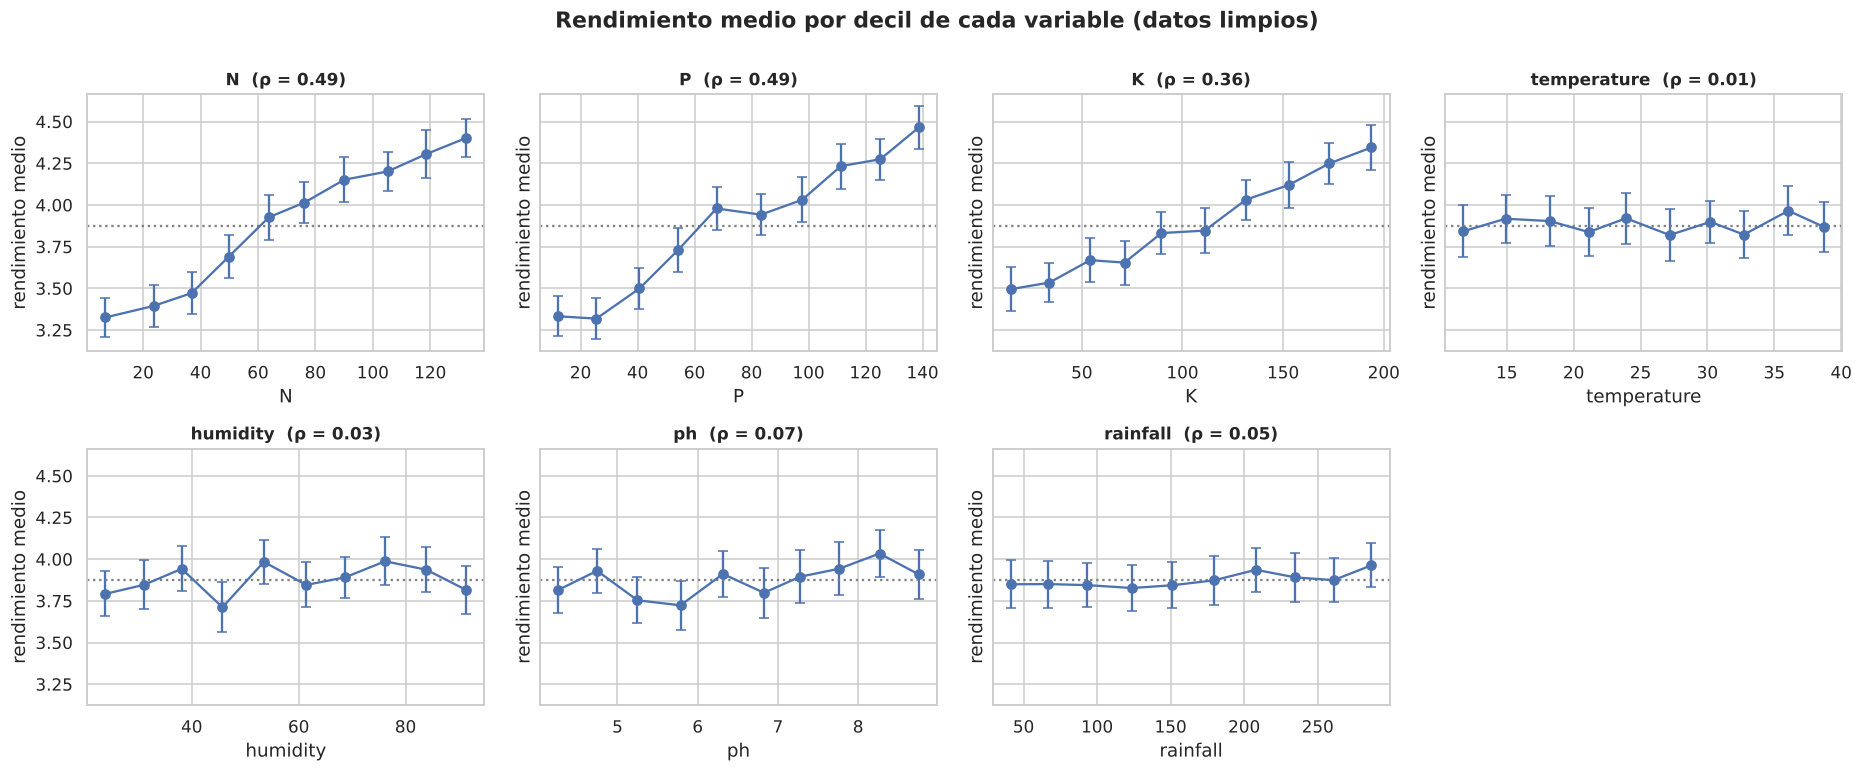

In [25]:
def tendencia_deciles(ax, serie, objetivo, nombre):
    d = pd.DataFrame({"x": serie, "y": objetivo}).dropna()
    d["bin"] = pd.qcut(d["x"], 10, duplicates="drop")
    g = d.groupby("bin", observed=True).agg(x=("x", "mean"), m=("y", "mean"),
                                           se=("y", lambda v: v.std(ddof=1) / np.sqrt(len(v))))
    ax.errorbar(g["x"], g["m"], yerr=1.96 * g["se"], marker="o", capsize=3, color="#4C72B0")
    ax.axhline(objetivo.mean(), color="gray", ls=":")
    rho = stats.spearmanr(d["x"], d["y"])[0]
    ax.set(title=f"{nombre}  (ρ = {rho:.2f})", xlabel=nombre, ylabel="rendimiento medio")

fig, axes = plt.subplots(2, 4, figsize=(17, 7), sharey=True)
for ax, c in zip(axes.ravel(), num_pred):
    tendencia_deciles(ax, df_clean[c], df_clean["yield_ton_ha"], c)
axes.ravel()[-1].axis("off")
plt.suptitle("Rendimiento medio por decil de cada variable (datos limpios)", y=1.0, fontweight="bold")
plt.tight_layout(); guardar_fig("09_relacion_con_el_objetivo"); plt.show()

Aquí se ve con claridad lo que anticipaba la correlación. `N`, `P` y `K` suben de forma sostenida y bastante recta: del decil más bajo al más alto, el rendimiento medio pasa de unos 3,3 a 4,4 t/ha con `N` y con `P`, y de 3,5 a 4,35 con `K`. No hay señales de saturación ni de un óptimo intermedio.

`temperature`, `humidity`, `ph` y `rainfall` son planas: todos los puntos oscilan alrededor de la media global dentro de su intervalo de confianza. Esto sugiere que un modelo lineal debería capturar casi todo lo capturable y que los modelos de árboles no tienen mucho que ganar frente a una relación así.

## 7. Preparación de X e y

Las predictoras salen del análisis anterior: las siete variables numéricas de suelo y clima más `soil_type`. El objetivo es `yield_ton_ha`.

In [26]:
TARGET = "yield_ton_ha"
FEATURES_NUM = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
FEATURES_CAT = ["soil_type"]
FEATURES = FEATURES_NUM + FEATURES_CAT

X = df_clean[FEATURES].copy()
y = df_clean[TARGET].copy()

assert TARGET not in X.columns, "el objetivo no puede estar en X"
assert not ({"label", "FarmID", "rainfall_inches", "RecordID"} & set(X.columns)), "columna descartada en X"
assert len(X) == len(y)
print(f"X: {X.shape} | y: {y.shape}")
print("Predictoras numéricas :", FEATURES_NUM)
print("Predictoras categóricas:", FEATURES_CAT)

X: (1200, 8) | y: (1200,)
Predictoras numéricas : ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
Predictoras categóricas: ['soil_type']


## 8. División en entrenamiento y prueba (80 / 20)

La división se hace **antes** de entrenar cualquier cosa y antes de aprender cualquier transformación. El conjunto de prueba hace de «datos futuros que nunca se vieron»; si algo calculado con esas filas (una mediana, una media, un modelo elegido mirando su error) llega al entrenamiento, la métrica final sale optimista y ya no mide cómo se comportará el modelo con fincas nuevas.

Por eso las medianas para imputar, las medias y desviaciones del escalado y las categorías del *one-hot* se aprenden solo con el 80 % de entrenamiento y después se aplican tal cual al 20 % de prueba. Con la misma lógica, toda la selección de modelos e hiperparámetros se hace con validación cruzada dentro de entrenamiento, y el conjunto de prueba se usa una sola vez para la evaluación final.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED)

print(f"Entrenamiento: {X_train.shape[0]} filas ({X_train.shape[0] / len(X):.0%}) | Prueba: {X_test.shape[0]} filas ({X_test.shape[0] / len(X):.0%})")
comparacion = pd.DataFrame({"train": y_train.describe(), "test": y_test.describe()})
display(comparacion.T)
ks = stats.ks_2samp(y_train, y_test)
print(f"Kolmogorov-Smirnov entre train y test (rendimiento): p = {ks.pvalue:.3f}")

Entrenamiento: 960 filas (80%) | Prueba: 240 filas (20%)


,count,mean,std,min,25%,50%,75%,max
train,960.000,3.887,0.775,1.268,3.345,3.883,4.424,6.021
test,240.000,3.827,0.758,1.901,3.280,3.874,4.347,5.801


Kolmogorov-Smirnov entre train y test (rendimiento): p = 0.639


Los dos conjuntos son parecidos: media de 3,887 frente a 3,827 y desviación de 0,775 frente a 0,758. La prueba de Kolmogorov-Smirnov no encuentra diferencias entre las distribuciones (p = 0,639), así que la partición aleatoria simple es suficiente y no hace falta estratificar. Como `FarmID` no tiene efecto (visto en 5.5), tampoco hace falta separar por fincas.

## 9. Preprocesamiento dentro de un pipeline

- **Numéricas:** imputación con la **mediana** + `StandardScaler`.
- **`soil_type`:** los faltantes se rellenan con una categoría explícita `"Desconocido"` y luego *one-hot encoding* con `handle_unknown="ignore"` (si aparece un suelo nuevo en producción no rompe el modelo).

Todo vive dentro de un `ColumnTransformer` que forma parte del `Pipeline` de cada modelo. Dentro de la validación cruzada eso significa que en cada pliegue el imputador y el escalador se ajustan solo con las filas de entrenamiento de ese pliegue.

In [28]:
def construir_preprocesador(imputador_num=None, incluir_categorica=True):
    imputador_num = imputador_num if imputador_num is not None else SimpleImputer(strategy="median")
    numericas = Pipeline([("imp", imputador_num), ("esc", StandardScaler())])
    transformadores = [("num", numericas, FEATURES_NUM)]
    if incluir_categorica:
        categorica = Pipeline([
            ("imp", SimpleImputer(strategy="constant", fill_value="Desconocido")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ])
        transformadores.append(("cat", categorica, FEATURES_CAT))
    return ColumnTransformer(transformadores, remainder="drop", verbose_feature_names_out=False)

preprocesador = construir_preprocesador()

# Demostración: lo que se aprende sale solo del entrenamiento
demo = clone(preprocesador).fit(X_train)
imp = demo.named_transformers_["num"].named_steps["imp"]
aprendidas = pd.DataFrame({"mediana_aprendida_en_train": imp.statistics_,
                           "mediana_de_todo_el_dataset": X[FEATURES_NUM].median().values,
                           "mediana_de_test": X_test[FEATURES_NUM].median().values}, index=FEATURES_NUM)
display(aprendidas)
Xt = demo.transform(X_train)
print(f"X_train transformada: {Xt.shape} | NaN restantes: {int(np.isnan(Xt).sum())}")
print("Columnas de salida:", list(demo.get_feature_names_out()))

,mediana_aprendida_en_train,mediana_de_todo_el_dataset,mediana_de_test
N,70.000,70.000,66.000
P,75.000,75.000,76.000
K,99.000,99.000,97.000
temperature,25.400,25.539,25.951
humidity,57.175,57.658,59.147
ph,6.483,6.575,6.878
rainfall,163.438,165.628,171.160


X_train transformada: (960, 30) | NaN restantes: 0
Columnas de salida: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'soil_type_Chalky', 'soil_type_Clay', 'soil_type_Desconocido', 'soil_type_Loamy', 'soil_type_Other', 'soil_type_Peaty', 'soil_type_Sandy', 'soil_type_Silty', 'soil_type_Type0', 'soil_type_Type1', 'soil_type_Type10', 'soil_type_Type11', 'soil_type_Type12', 'soil_type_Type13', 'soil_type_Type14', 'soil_type_Type2', 'soil_type_Type3', 'soil_type_Type4', 'soil_type_Type5', 'soil_type_Type6', 'soil_type_Type7', 'soil_type_Type8', 'soil_type_Type9']


La tabla muestra por qué importa ajustar el preprocesador solo con el entrenamiento. Las medianas aprendidas no son las de todo el dataset ni las de test: por ejemplo la de `ph` es 6,483 en train, 6,575 en todo el dataset y 6,878 en test. Si se hubiera imputado con la mediana global, los datos de prueba habrían influido en cómo se rellenan los datos de entrenamiento, que es justo el tipo de contaminación que se quiere evitar.

La salida tiene 30 columnas (las 7 numéricas estandarizadas más 23 del *one-hot* de `soil_type`: 22 tipos y «Desconocido») y ningún valor faltante.

### 9.1 Dos decisiones que conviene comprobar con datos

Hasta aquí algunas decisiones (imputar con la mediana, conservar `soil_type`, tratar los extremos) se tomaron con argumentos. Antes de seguir se contrastan con validación cruzada de 5 pliegues, solo dentro de entrenamiento y con dos modelos de naturaleza distinta: una regresión Ridge (lineal, sensible a valores extremos) y un Gradient Boosting (árboles, más robusto). Si una alternativa más sofisticada no mejora, no se justifica complicar el pipeline.

In [29]:
CV = KFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = {"rmse": "neg_root_mean_squared_error", "r2": "r2", "mae": "neg_mean_absolute_error"}

def rmse(y_real, y_pred):
    return float(np.sqrt(mean_squared_error(y_real, y_pred)))

def evaluar_cv(prep, modelo, Xd=None):
    Xd = X_train if Xd is None else Xd
    pipe = Pipeline([("prep", prep), ("model", modelo)])
    r = cross_validate(pipe, Xd, y_train, cv=CV, scoring=SCORING, n_jobs=-1)
    return {"rmse": -r["test_rmse"].mean(), "rmse_std": r["test_rmse"].std(), "r2": r["test_r2"].mean()}

modelos_ref = {"Ridge": Ridge(alpha=1.0),
               "Gradient Boosting": GradientBoostingRegressor(n_estimators=150, learning_rate=0.05, max_depth=3, random_state=SEED)}

# (a) Estrategia de imputación de las numéricas
variantes_imp = {
    "Mediana (elegida)": SimpleImputer(strategy="median"),
    "Media": SimpleImputer(strategy="mean"),
    "Mediana + indicador de faltante": SimpleImputer(strategy="median", add_indicator=True),
    "KNN (k=5)": KNNImputer(n_neighbors=5),
    "Iterativa (regresión bayesiana)": IterativeImputer(random_state=SEED, max_iter=10),
}
filas = []
for nombre_imp, imputador in variantes_imp.items():
    for nombre_mod, modelo in modelos_ref.items():
        r = evaluar_cv(construir_preprocesador(imputador), modelo)
        filas.append({"imputación": nombre_imp, "modelo": nombre_mod, "RMSE_cv": r["rmse"], "desv": r["rmse_std"], "R2_cv": r["r2"]})
tabla_imp = pd.DataFrame(filas).pivot(index="imputación", columns="modelo", values=["RMSE_cv", "R2_cv"])
display(tabla_imp)

RMSE_cv                   R2_cv  \
modelo                          Gradient Boosting Ridge Gradient Boosting   
imputación                                                                  
Iterativa (regresión bayesiana)             0.537 0.522             0.514   
KNN (k=5)                                   0.539 0.527             0.510   
Media                                       0.537 0.522             0.514   
Mediana (elegida)                           0.537 0.522             0.513   
Mediana + indicador de faltante             0.539 0.526             0.510   

                                       
modelo                          Ridge  
imputación                             
Iterativa (regresión bayesiana) 0.539  
KNN (k=5)                       0.530  
Media                           0.539  
Mediana (elegida)               0.539  
Mediana + indicador de faltante 0.531

Las cinco estrategias dan resultados prácticamente iguales: con Ridge el RMSE va de 0,522 a 0,527 y con Gradient Boosting de 0,537 a 0,539, diferencias muy por debajo de la desviación entre pliegues (alrededor de 0,04). Ninguna de las alternativas más elaboradas (KNN, iterativa, indicador de faltante) supera a la mediana. Tiene sentido con lo visto antes: como las predictoras son casi independientes entre sí, no hay información en las otras columnas con la que adivinar mejor un valor faltante. Se mantiene la **mediana**, que es la más simple y la más robusta.

In [30]:
# (b) ¿Aporta algo soil_type?
filas = []
for nombre_mod, modelo in modelos_ref.items():
    for etiqueta, incluir in [("con soil_type", True), ("sin soil_type", False)]:
        r = evaluar_cv(construir_preprocesador(incluir_categorica=incluir), modelo)
        filas.append({"modelo": nombre_mod, "variante": etiqueta, "RMSE_cv": r["rmse"], "desv": r["rmse_std"], "R2_cv": r["r2"]})
pd.DataFrame(filas).set_index(["modelo", "variante"])

RMSE_cv  desv  R2_cv
modelo            variante                           
Ridge             con soil_type    0.522 0.040  0.539
                  sin soil_type    0.510 0.040  0.560
Gradient Boosting con soil_type    0.537 0.039  0.513
                  sin soil_type    0.535 0.040  0.518

Quitar `soil_type` no empeora nada, al contrario: con Ridge el RMSE baja de 0,522 a 0,510 y con Gradient Boosting de 0,537 a 0,535. Las 23 columnas del *one-hot* están metiendo ruido. Esta es una conclusión incómoda pero honesta: en estos datos el tipo de suelo no aporta información útil.

Aun así lo dejo en el pipeline para los siete modelos, porque forma parte del planteamiento del proyecto y porque el resultado final permite ver qué hace cada modelo con una variable inútil (Lasso, como se verá, la neutraliza por completo). Si el modelo elegido la ignora, el costo de tenerla es nulo.

In [31]:
# (c) Impacto del tratamiento de valores inválidos: se entrena con datos sin tratar y se valida con datos tratados
X_train_raw = df_raw.loc[X_train.index, FEATURES].copy()   # mismas filas, valores originales
filas = []
for nombre_mod, modelo in modelos_ref.items():
    errores = {"entrenando con datos sin tratar": [], "entrenando con datos tratados": []}
    for tr, va in CV.split(X_train):
        for etiqueta, Xtr in [("entrenando con datos sin tratar", X_train_raw), ("entrenando con datos tratados", X_train)]:
            pipe = Pipeline([("prep", clone(preprocesador)), ("model", clone(modelo))])
            pipe.fit(Xtr.iloc[tr], y_train.iloc[tr])
            errores[etiqueta].append(rmse(y_train.iloc[va], pipe.predict(X_train.iloc[va])))
    for etiqueta, e in errores.items():
        filas.append({"modelo": nombre_mod, "escenario": etiqueta, "RMSE_cv": np.mean(e), "desv": np.std(e)})
pd.DataFrame(filas).set_index(["modelo", "escenario"])

RMSE_cv  desv
modelo            escenario                                     
Ridge             entrenando con datos sin tratar    0.538 0.037
                  entrenando con datos tratados      0.522 0.040
Gradient Boosting entrenando con datos sin tratar    0.540 0.039
                  entrenando con datos tratados      0.537 0.039

El efecto existe pero depende del tipo de modelo. Con Ridge, que es lineal y por lo tanto sensible a puntos extremos, el RMSE baja de 0,538 a 0,522 (casi un 3 %) solo por haber tratado el 2 % de las filas. Con Gradient Boosting, mucho menos sensible a los valores atípicos, la diferencia es casi nula (0,540 frente a 0,537). Esto va en línea con la teoría: un `N = 500` o un `rainfall = 2000` son puntos de gran apalancamiento que tuercen una recta, mientras que un árbol simplemente los aísla en una hoja.

Por lo tanto el tratamiento no es un adorno: es necesario para los modelos lineales, que como se verá acaban siendo los mejores.

## 10. Entrenamiento de los 7 modelos de regresión

Se entrenan siete modelos de familias distintas, todos con el mismo preprocesamiento y los mismos pliegues de validación cruzada para que la comparación sea justa:

1. Regresión lineal (referencia sin regularización)
2. Ridge (lineal con penalización L2)
3. Lasso (lineal con penalización L1, puede anular coeficientes)
4. KNN (basado en vecinos)
5. SVR con kernel RBF
6. Random Forest
7. Gradient Boosting

Cada uno recibe una búsqueda de hiperparámetros pequeña pero razonable (`GridSearchCV`, 5 pliegues, optimizando RMSE), de modo que ninguno compita con los parámetros por defecto frente a otro afinado. Además se incluye una **línea base** que siempre predice la media de entrenamiento (no cuenta como uno de los siete): cualquier modelo que no la supere de forma clara no está aprendiendo nada útil.

In [32]:
MODELOS = {
    "Regresión lineal": (LinearRegression(), {}),
    "Ridge": (Ridge(), {"model__alpha": [0.1, 1, 10, 100, 300, 1000]}),
    "Lasso": (Lasso(max_iter=20000), {"model__alpha": [0.0005, 0.001, 0.01, 0.05, 0.1]}),
    "KNN": (KNeighborsRegressor(), {"model__n_neighbors": [5, 10, 15, 25, 40, 60], "model__weights": ["uniform", "distance"]}),
    "SVR": (SVR(kernel="rbf"), {"model__C": [0.1, 0.3, 1, 3], "model__epsilon": [0.05, 0.1, 0.3], "model__gamma": ["scale", 0.005, 0.01, 0.02]}),
    "Random Forest": (RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=1),
                      {"model__max_depth": [4, 8, None], "model__min_samples_leaf": [5, 10, 20, 40], "model__max_features": [0.3, 0.6, 1.0]}),
    "Gradient Boosting": (GradientBoostingRegressor(random_state=SEED),
                          {"model__n_estimators": [100, 200, 400], "model__learning_rate": [0.01, 0.03, 0.1],
                           "model__max_depth": [1, 2, 3], "model__subsample": [0.7, 1.0]}),
}

def metricas(y_real, y_pred):
    return {"R2": r2_score(y_real, y_pred), "RMSE": rmse(y_real, y_pred),
            "MAE": mean_absolute_error(y_real, y_pred), "MAPE_%": mean_absolute_percentage_error(y_real, y_pred) * 100}

busquedas, filas = {}, []
for nombre, (estimador, grilla) in MODELOS.items():
    pipe = Pipeline([("prep", clone(preprocesador)), ("model", estimador)])
    t0 = time.time()
    gs = GridSearchCV(pipe, grilla, cv=CV, scoring=SCORING, refit="rmse", n_jobs=-1, return_train_score=True)
    gs.fit(X_train, y_train)
    seg = time.time() - t0
    busquedas[nombre] = gs
    i, cr = gs.best_index_, gs.cv_results_
    pred_te = gs.predict(X_test)
    m_te = metricas(y_test, pred_te)
    filas.append({
        "modelo": nombre,
        "mejores_parametros": {k.replace("model__", ""): v for k, v in gs.best_params_.items()},
        "cv_rmse": -cr["mean_test_rmse"][i], "cv_rmse_std": cr["std_test_rmse"][i],
        "cv_r2": cr["mean_test_r2"][i], "train_r2": cr["mean_train_r2"][i],
        "test_r2": m_te["R2"], "test_rmse": m_te["RMSE"], "test_mae": m_te["MAE"], "test_mape_%": m_te["MAPE_%"],
        "segundos": seg,
    })
    print(f"{nombre:18s} CV RMSE = {-cr['mean_test_rmse'][i]:.4f}   ({seg:5.1f} s)")

# Línea base: predice siempre la media de entrenamiento
base = Pipeline([("prep", clone(preprocesador)), ("model", DummyRegressor(strategy="mean"))])
cv_base = cross_validate(base, X_train, y_train, cv=CV, scoring=SCORING)
base.fit(X_train, y_train)
m_base = metricas(y_test, base.predict(X_test))
print(f"{'Línea base (media)':18s} CV RMSE = {-cv_base['test_rmse'].mean():.4f}")

Regresión lineal   CV RMSE = 0.5223   (  0.1 s)


Ridge              CV RMSE = 0.5163   (  0.5 s)


Lasso              CV RMSE = 0.5105   (  0.5 s)


KNN                CV RMSE = 0.5549   (  1.4 s)


SVR                CV RMSE = 0.5138   ( 11.4 s)


Random Forest      CV RMSE = 0.5341   ( 36.0 s)


Gradient Boosting  CV RMSE = 0.5260   ( 45.7 s)
Línea base (media) CV RMSE = 0.7752


## 11. Evaluación y comparación de los modelos

Se reportan tres cosas por modelo: el desempeño en validación cruzada (que es lo que se usa para decidir), el desempeño en entrenamiento (para detectar sobreajuste) y el desempeño en prueba, que se calcula una sola vez y solo sirve para confirmar.

- **RMSE** y **MAE** están en toneladas por hectárea, la misma unidad del objetivo. El RMSE castiga más los errores grandes.
- **R²** es la fracción de la variabilidad del rendimiento que explica el modelo (0 = no mejora a predecir siempre la media).
- **MAPE** es el error porcentual medio. Se incluye por ser fácil de leer, aunque con rendimientos cercanos a 1 t/ha puede inflarse.

In [33]:
tabla = pd.DataFrame(filas).set_index("modelo").sort_values("cv_rmse")
tabla["gap_train_cv_r2"] = tabla["train_r2"] - tabla["cv_r2"]

linea_base = pd.Series({"cv_rmse": -cv_base["test_rmse"].mean(), "cv_rmse_std": cv_base["test_rmse"].std(),
                        "cv_r2": cv_base["test_r2"].mean(), "test_r2": m_base["R2"], "test_rmse": m_base["RMSE"],
                        "test_mae": m_base["MAE"], "test_mape_%": m_base["MAPE_%"]}, name="Línea base (media)")

columnas = ["cv_rmse", "cv_rmse_std", "cv_r2", "train_r2", "gap_train_cv_r2", "test_r2", "test_rmse", "test_mae", "test_mape_%"]
display(pd.concat([tabla[columnas], linea_base.to_frame().T[["cv_rmse", "cv_rmse_std", "cv_r2", "test_r2", "test_rmse", "test_mae", "test_mape_%"]]]))
print("\nMejores hiperparámetros:")
for n, p in tabla["mejores_parametros"].items():
    print(f"  {n:18s} {p}")

,cv_rmse,cv_rmse_std,cv_r2,train_r2,gap_train_cv_r2,test_r2,test_rmse,test_mae,test_mape_%
Lasso,0.510,0.039,0.560,0.571,0.011,0.488,0.541,0.433,12.536
SVR,0.514,0.035,0.554,0.577,0.022,0.487,0.541,0.431,12.517
Ridge,0.516,0.035,0.550,0.568,0.018,0.490,0.540,0.430,12.486
Regresión lineal,0.522,0.040,0.538,0.582,0.043,0.472,0.549,0.435,12.593
Gradient Boosting,0.526,0.038,0.534,0.604,0.070,0.459,0.556,0.447,13.014
Random Forest,0.534,0.037,0.518,0.745,0.227,0.437,0.567,0.454,13.264
KNN,0.555,0.028,0.482,1.000,0.518,0.430,0.571,0.453,13.277
Línea base (media),0.775,0.034,-0.009,NaN,NaN,-0.006,0.758,0.617,17.924



Mejores hiperparámetros:
  Lasso              {'alpha': 0.01}
  SVR                {'C': 1, 'epsilon': 0.1, 'gamma': 0.005}
  Ridge              {'alpha': 100}
  Regresión lineal   {}
  Gradient Boosting  {'learning_rate': 0.03, 'max_depth': 1, 'n_estimators': 400, 'subsample': 0.7}
  Random Forest      {'max_depth': 8, 'max_features': 0.6, 'min_samples_leaf': 5}
  KNN                {'n_neighbors': 25, 'weights': 'distance'}


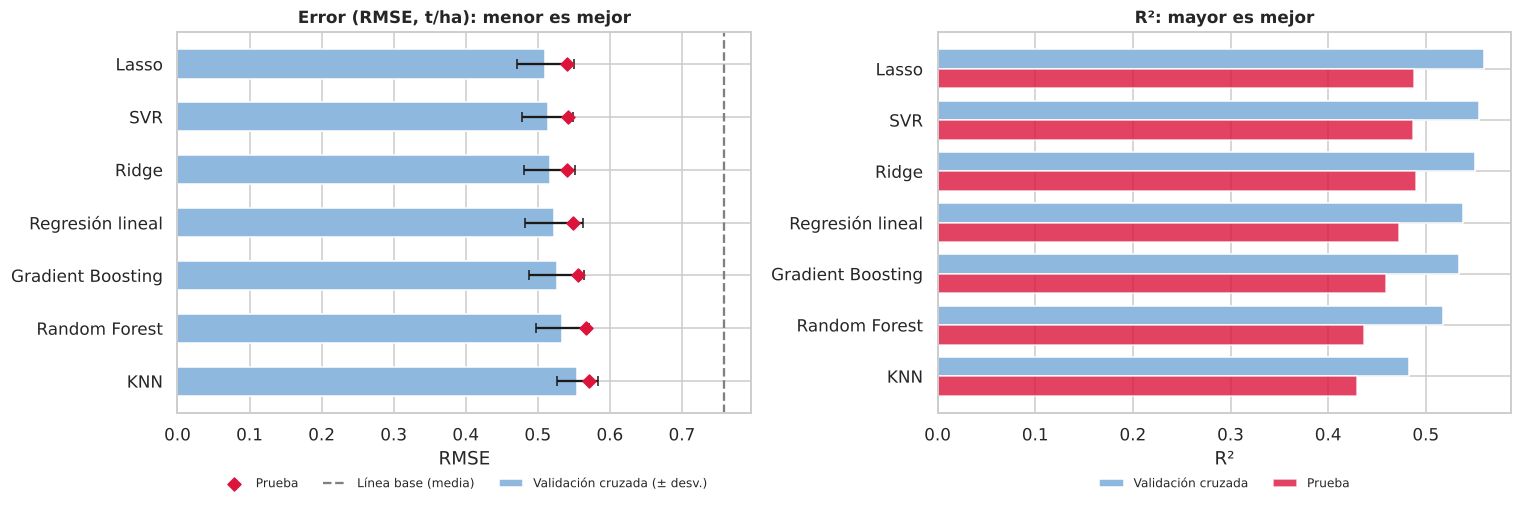

In [34]:
orden = tabla.index.tolist()
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))

pos = np.arange(len(orden))
ax[0].barh(pos, tabla["cv_rmse"], xerr=tabla["cv_rmse_std"], color="#8FB8DE", label="Validación cruzada (± desv.)", capsize=3, height=0.55)
ax[0].scatter(tabla["test_rmse"], pos, color="crimson", marker="D", zorder=3, label="Prueba")
ax[0].axvline(linea_base["test_rmse"], color="gray", ls="--", label="Línea base (media)")
ax[0].set_yticks(pos); ax[0].set_yticklabels(orden); ax[0].invert_yaxis()
ax[0].set(title="Error (RMSE, t/ha): menor es mejor", xlabel="RMSE"); ax[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=3, fontsize=8, frameon=False)

ancho = 0.38
ax[1].barh(pos - ancho / 2, tabla["cv_r2"], height=ancho, color="#8FB8DE", label="Validación cruzada")
ax[1].barh(pos + ancho / 2, tabla["test_r2"], height=ancho, color="crimson", alpha=0.8, label="Prueba")
ax[1].set_yticks(pos); ax[1].set_yticklabels(orden); ax[1].invert_yaxis()
ax[1].set(title="R²: mayor es mejor", xlabel="R²"); ax[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2, fontsize=8, frameon=False)
plt.tight_layout(); guardar_fig("10_comparacion_modelos"); plt.show()

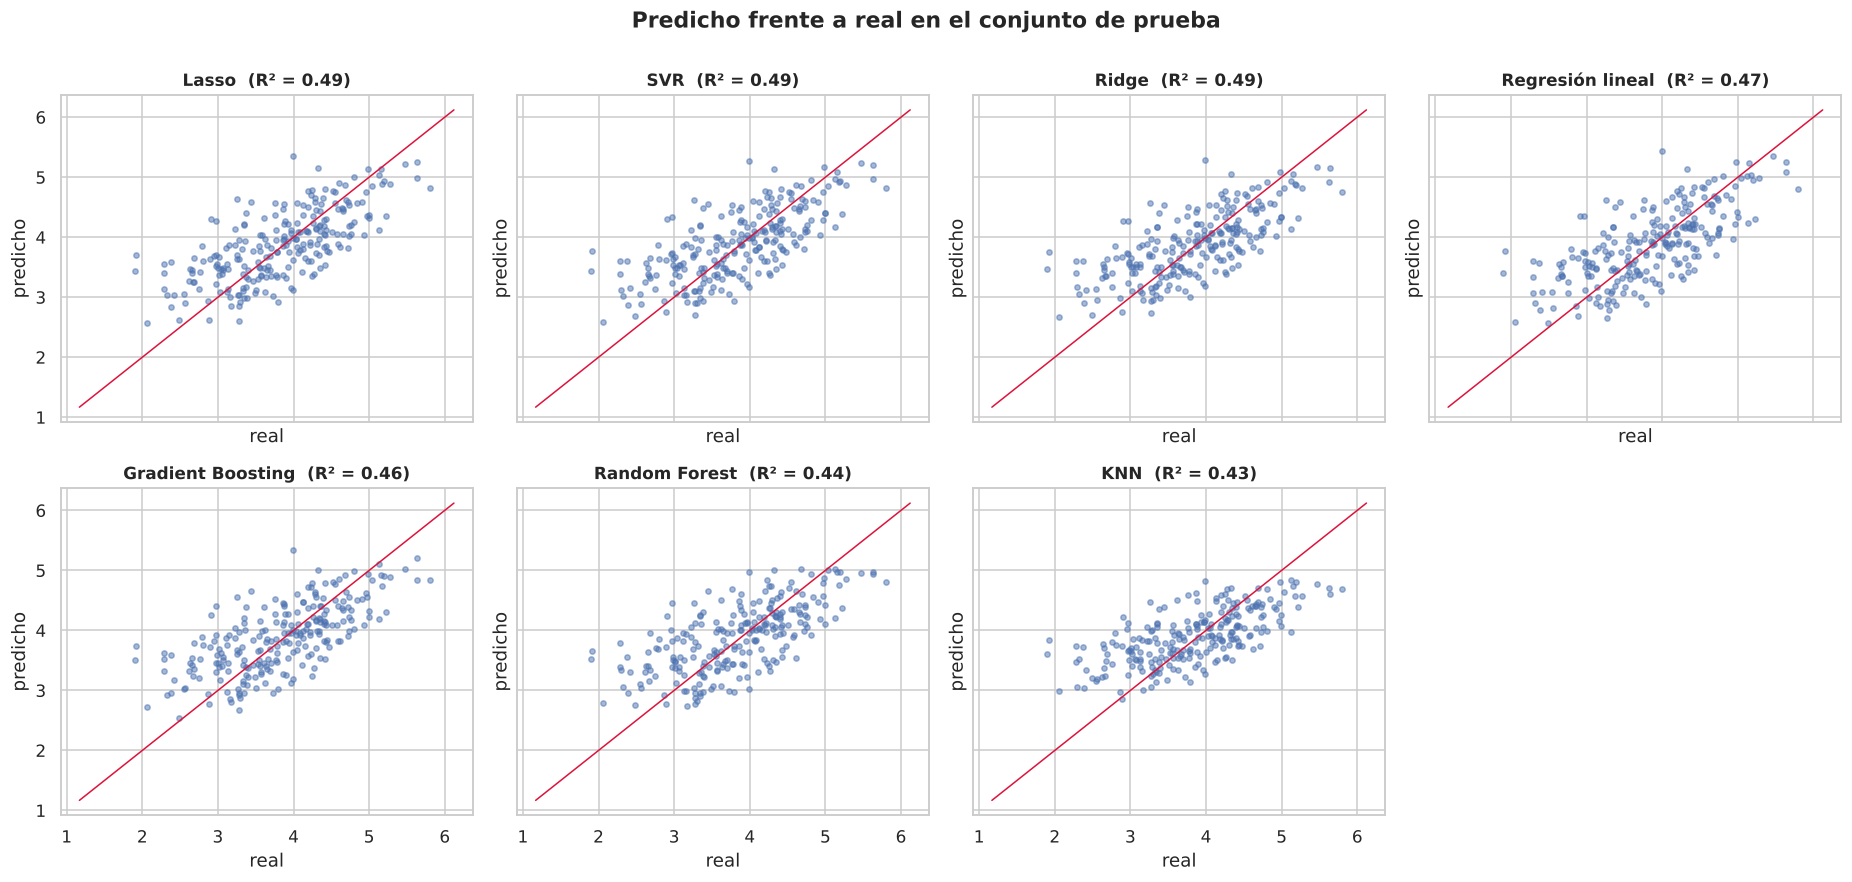

In [35]:
fig, axes = plt.subplots(2, 4, figsize=(17, 8), sharex=True, sharey=True)
lim = [y.min() - 0.1, y.max() + 0.1]
for ax, nombre in zip(axes.ravel(), orden):
    pred = busquedas[nombre].predict(X_test)
    ax.scatter(y_test, pred, s=12, alpha=0.5)
    ax.plot(lim, lim, color="crimson", lw=1)
    ax.set_title(f"{nombre}  (R² = {r2_score(y_test, pred):.2f})")
    ax.set(xlabel="real", ylabel="predicho")
axes.ravel()[-1].axis("off")
plt.suptitle("Predicho frente a real en el conjunto de prueba", y=1.0, fontweight="bold")
plt.tight_layout(); guardar_fig("11_predicho_vs_real"); plt.show()

**Todos los modelos superan con claridad a la línea base** (RMSE en validación de 0,775 t/ha para la media frente a 0,51–0,56 para los modelos), así que sí hay algo que aprender.

**Los modelos simples ganan.** Lasso (0,510), SVR (0,514), Ridge (0,516), regresión lineal (0,522) y Gradient Boosting (0,526) quedan muy juntos, con R² de validación entre 0,53 y 0,56. Random Forest (0,534) y KNN (0,555) van por detrás. Esto cuadra con lo visto en el EDA: la relación es casi lineal en tres variables, y no hay estructura compleja que los árboles o los vecinos puedan aprovechar.

**El sobreajuste se ve en la brecha entre entrenamiento y validación.** KNN memoriza (R² de entrenamiento 1,00 frente a 0,48 en validación) y Random Forest también se pasa (0,745 frente a 0,518). Los modelos lineales casi no tienen brecha (entre 0,01 y 0,04), lo que indica que generalizan bien.

**En prueba todos puntúan un poco peor que en validación** (R² entre 0,43 y 0,49, RMSE entre 0,54 y 0,57). Es una diferencia de unos 0,03 t/ha, menor que la desviación entre pliegues (0,04) y común a todos los modelos, así que se atribuye a la variabilidad de evaluar con solo 240 filas, no a un problema del proceso. El orden relativo de los modelos se mantiene.

En los gráficos de predicho frente a real los puntos siguen la diagonal pero con mucha dispersión, y todos los modelos tienden a «aplastar» los extremos hacia el centro: comportamiento típico cuando el R² ronda 0,5.

## 12. Selección del mejor modelo

El criterio es el error de **validación cruzada** (RMSE), no el de prueba, para no elegir mirando el conjunto que debe quedar intacto. Como las diferencias entre modelos pueden ser menores que el ruido entre pliegues, se calcula también qué modelos quedan **empatados** con el mejor, es decir, dentro de un error estándar de su RMSE (la misma idea de la regla del error estándar de Hastie, Tibshirani y Friedman). Ese empate se tiene en cuenta al interpretar, pero la elección sigue siendo la del menor error de validación, fijada de antemano.

In [36]:
mejor_cv = tabla["cv_rmse"].idxmin()
umbral = tabla.loc[mejor_cv, "cv_rmse"] + tabla.loc[mejor_cv, "cv_rmse_std"] / np.sqrt(CV.get_n_splits())
empatados = tabla[tabla["cv_rmse"] <= umbral].index.tolist()
ELEGIDO = mejor_cv

print(f"Menor RMSE en validación cruzada: {mejor_cv} ({tabla.loc[mejor_cv, 'cv_rmse']:.4f})")
print(f"Umbral (mejor + 1 error estándar): {umbral:.4f}")
print(f"Modelos empatados con el mejor dentro de ese umbral: {empatados}")
print(f"\nModelo elegido: {ELEGIDO}")

modelo_final = busquedas[ELEGIDO].best_estimator_
pred_test = modelo_final.predict(X_test)
final_test = metricas(y_test, pred_test)
final_cv = tabla.loc[ELEGIDO, ["cv_rmse", "cv_rmse_std", "cv_r2"]].to_dict()
print("\nDesempeño final en prueba:", {k: round(v, 4) for k, v in final_test.items()})
print("Mejora del RMSE frente a la línea base:", f"{1 - final_test['RMSE'] / m_base['RMSE']:.1%}")

Menor RMSE en validación cruzada: Lasso (0.5105)
Umbral (mejor + 1 error estándar): 0.5280
Modelos empatados con el mejor dentro de ese umbral: ['Lasso', 'SVR', 'Ridge', 'Regresión lineal', 'Gradient Boosting']

Modelo elegido: Lasso

Desempeño final en prueba: {'R2': 0.4877, 'RMSE': 0.5411, 'MAE': 0.4333, 'MAPE_%': 12.536}
Mejora del RMSE frente a la línea base: 28.6%


Lasso tiene el menor RMSE de validación (0,5105, con `alpha = 0,01`). Hay que ser honesto con que no gana por mucho: otros cuatro modelos (SVR, Ridge, regresión lineal y Gradient Boosting) quedan dentro de un error estándar, así que con estos datos no se puede afirmar que Lasso sea mejor que ellos en sentido estricto. Se elige igualmente por el criterio acordado de antemano (menor error de validación) y porque tiene ventajas que los demás no ofrecen a la vez: es interpretable, casi no se sobreajusta y hace selección de variables por sí mismo.

En el conjunto de prueba, evaluado una sola vez: **R² = 0,488, RMSE = 0,541 t/ha, MAE = 0,433 t/ha** (error porcentual medio del 12,5 %). Respecto a la línea base, el error cuadrático baja un 28,6 %.

## 13. Interpretación de los resultados

### 13.1 ¿Qué variables importan?

Se usa **importancia por permutación** sobre el conjunto de prueba: se desordena una variable a la vez y se mide cuánto empeora el RMSE. Es independiente del tipo de modelo y se calcula sobre las variables originales (`soil_type` cuenta como una sola, no como sus 23 columnas *one-hot*).

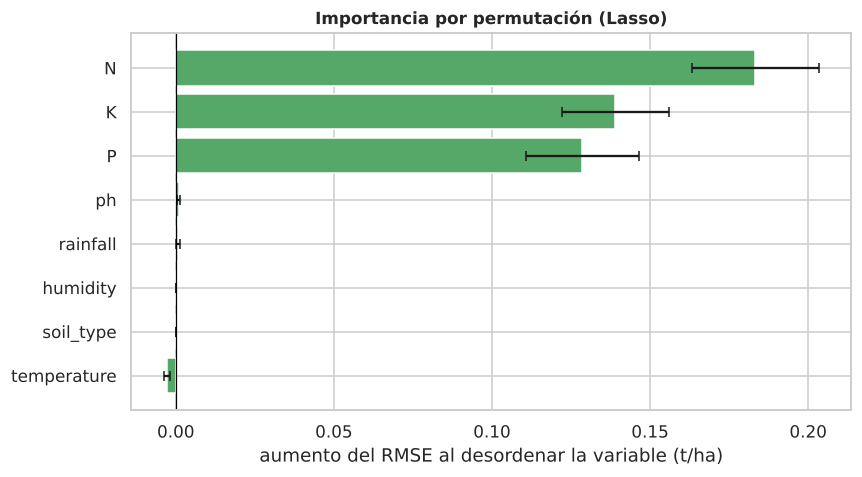

,aumento_rmse,desv
N,0.183,0.020
K,0.139,0.017
P,0.129,0.018
ph,0.001,0.001
rainfall,0.001,0.001
humidity,0.000,0.000
soil_type,0.000,0.000
temperature,-0.003,0.001


In [37]:
pi = permutation_importance(modelo_final, X_test, y_test, scoring="neg_root_mean_squared_error",
                            n_repeats=30, random_state=SEED, n_jobs=-1)
imp_df = pd.DataFrame({"aumento_rmse": pi.importances_mean, "desv": pi.importances_std}, index=FEATURES).sort_values("aumento_rmse", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(imp_df.index[::-1], imp_df["aumento_rmse"][::-1], xerr=imp_df["desv"][::-1], color="#55A868", capsize=3)
ax.axvline(0, color="black", lw=0.8)
ax.set(title=f"Importancia por permutación ({ELEGIDO})", xlabel="aumento del RMSE al desordenar la variable (t/ha)")
plt.tight_layout(); guardar_fig("12_importancia_permutacion"); plt.show()
imp_df

In [38]:
# Si el modelo elegido es lineal, los coeficientes (sobre variables estandarizadas) dan la magnitud y el signo
paso_modelo = modelo_final.named_steps["model"]
if hasattr(paso_modelo, "coef_"):
    nombres = modelo_final.named_steps["prep"].get_feature_names_out()
    coefs = pd.Series(paso_modelo.coef_, index=nombres)
    activos = coefs[coefs.abs() > 1e-12].sort_values(key=np.abs, ascending=False)
    print(f"Intercepto (rendimiento medio de entrenamiento): {paso_modelo.intercept_:.3f} t/ha")
    print(f"Coeficientes distintos de cero: {len(activos)} de {len(coefs)}")
    display(activos.to_frame("coeficiente (t/ha por desviación estándar)"))

Intercepto (rendimiento medio de entrenamiento): 3.887 t/ha
Coeficientes distintos de cero: 6 de 30


,coeficiente (t/ha por desviación estándar)
P,0.357
N,0.352
K,0.271
temperature,0.019
rainfall,0.011
ph,0.009


### 13.2 Forma de la relación

Los gráficos de dependencia parcial muestran el rendimiento que predice el modelo al variar una variable y dejar el resto como está, promediando sobre los datos de entrenamiento.

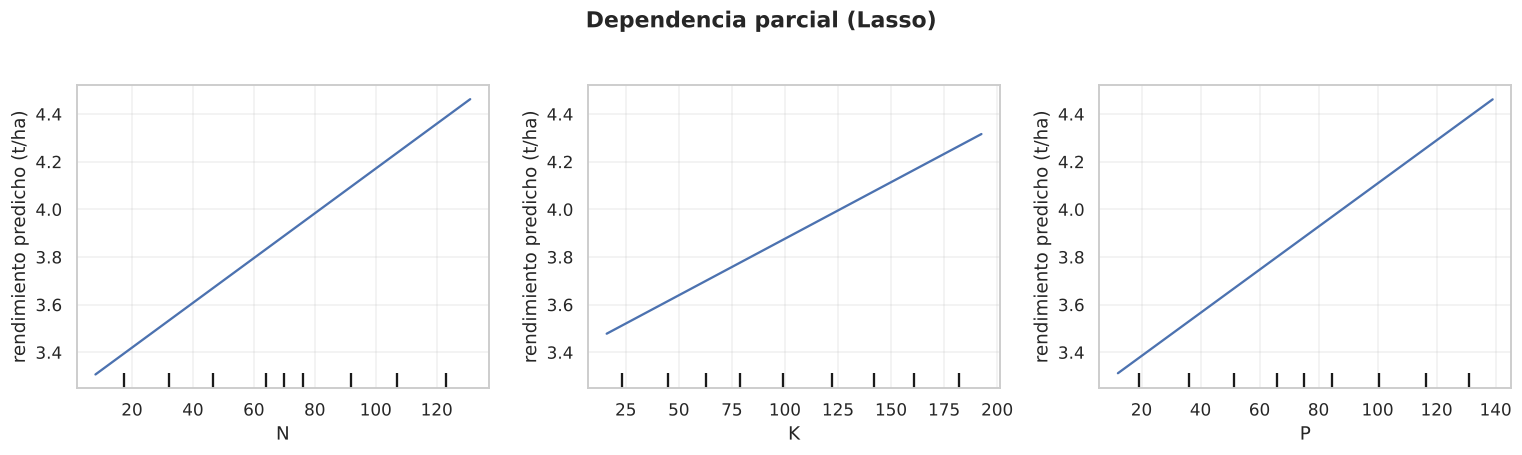

In [39]:
top_num = [f for f in imp_df.index if f in FEATURES_NUM][:3]
# La rejilla del gráfico se calcula con percentiles, que fallan si la columna tiene NaN (N y P los tienen):
# para dibujar se rellenan con la mediana de train; el pipeline sigue imputando soil_type por su cuenta.
X_pdp = X_train.copy()
X_pdp[FEATURES_NUM] = X_pdp[FEATURES_NUM].fillna(X_train[FEATURES_NUM].median())

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
PartialDependenceDisplay.from_estimator(modelo_final, X_pdp, features=top_num, kind="average",
                                        grid_resolution=30, ax=ax)
lims = [a.get_ylim() for a in ax]
for a in ax:
    a.set_ylim(min(l[0] for l in lims), max(l[1] for l in lims))
    a.set_ylabel("rendimiento predicho (t/ha)")
    a.grid(True, alpha=0.3)
plt.suptitle(f"Dependencia parcial ({ELEGIDO})", y=1.03, fontweight="bold")
plt.tight_layout(); guardar_fig("13_dependencia_parcial"); plt.show()

Los números son muy rotundos. Desordenar `N` empeora el RMSE en 0,18 t/ha, `K` en 0,14 y `P` en 0,13. Desordenar cualquiera de las otras cinco variables (`temperature`, `humidity`, `ph`, `rainfall`, `soil_type`) cambia el error en 0,003 t/ha o menos, es decir, nada.

Lasso lo confirma por su cuenta: de los 30 coeficientes, 24 quedan exactamente en cero, incluyendo los 23 de `soil_type`. Sobreviven los de `P` (0,357), `N` (0,352) y `K` (0,271) más tres casi nulos (`temperature` 0,019, `rainfall` 0,011, `ph` 0,009). Los coeficientes están en t/ha por desviación estándar de cada variable: una subida de una desviación estándar en `N` (unas 40 unidades) eleva el rendimiento esperado en unas 0,35 t/ha, con el resto fijo; `P` se comporta igual y `K` algo menos.

Como el modelo es lineal, los gráficos de dependencia parcial son rectas, y lo que informan es la pendiente: por ejemplo, en `K` el rendimiento predicho sube de unos 3,5 t/ha con `K` bajo a 4,3 con `K` alto.

### 13.3 Errores del modelo

Un R² por sí solo no dice si los errores son sistemáticos. Se revisa si los residuos (real − predicho) están centrados, si crecen con el nivel de rendimiento y si se parecen a una normal.

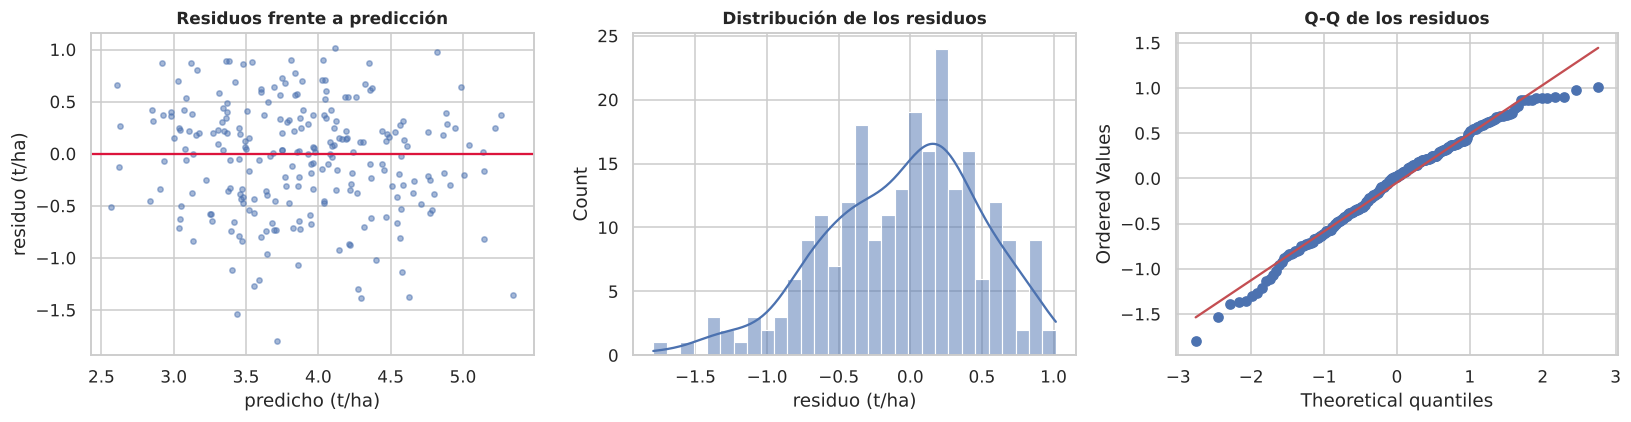

Residuo medio: -0.047 t/ha | desv. estándar: 0.540 t/ha
Shapiro-Wilk (normalidad de residuos): p = 0.005
Spearman entre |residuo| y predicción (heterocedasticidad): rho = -0.079 (p = 0.224)

Error absoluto medio según el nivel real de rendimiento:
                   MAE  sesgo (real − predicho)
yield_ton_ha                                   
rendimiento bajo 0.569                   -0.459
medio            0.317                    0.032
alto             0.414                    0.287


In [40]:
resid = y_test - pred_test
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].scatter(pred_test, resid, s=12, alpha=0.5); ax[0].axhline(0, color="crimson")
ax[0].set(title="Residuos frente a predicción", xlabel="predicho (t/ha)", ylabel="residuo (t/ha)")
sns.histplot(resid, kde=True, ax=ax[1], bins=30, color="#4C72B0"); ax[1].set(title="Distribución de los residuos", xlabel="residuo (t/ha)")
stats.probplot(resid, dist="norm", plot=ax[2]); ax[2].set_title("Q-Q de los residuos")
plt.tight_layout(); guardar_fig("14_residuos"); plt.show()

print(f"Residuo medio: {resid.mean():.3f} t/ha | desv. estándar: {resid.std():.3f} t/ha")
print(f"Shapiro-Wilk (normalidad de residuos): p = {stats.shapiro(resid).pvalue:.3f}")
rho_h, p_h = stats.spearmanr(pred_test, resid.abs())
print(f"Spearman entre |residuo| y predicción (heterocedasticidad): rho = {rho_h:.3f} (p = {p_h:.3f})")
terciles = pd.qcut(y_test, 3, labels=["rendimiento bajo", "medio", "alto"])
print("\nError absoluto medio según el nivel real de rendimiento:")
print(pd.DataFrame({"MAE": np.abs(resid).groupby(terciles, observed=True).mean(), "sesgo (real − predicho)": resid.groupby(terciles, observed=True).mean()}).round(3).to_string())

In [41]:
# Intervalo empírico de predicción: cuantiles de los residuos fuera de muestra en entrenamiento (validación cruzada)
oof = cross_val_predict(clone(modelo_final), X_train, y_train, cv=CV, n_jobs=-1)
res_oof = y_train - oof
q = {"q025": res_oof.quantile(0.025), "q05": res_oof.quantile(0.05), "q95": res_oof.quantile(0.95), "q975": res_oof.quantile(0.975)}
cob90 = ((y_test >= pred_test + q["q05"]) & (y_test <= pred_test + q["q95"])).mean()
cob95 = ((y_test >= pred_test + q["q025"]) & (y_test <= pred_test + q["q975"])).mean()
print(f"Intervalo del 90 %: predicción {q['q05']:+.2f} / {q['q95']:+.2f} t/ha  → cobertura real en prueba: {cob90:.1%}")
print(f"Intervalo del 95 %: predicción {q['q025']:+.2f} / {q['q975']:+.2f} t/ha  → cobertura real en prueba: {cob95:.1%}")

Intervalo del 90 %: predicción -0.82 / +0.83 t/ha  → cobertura real en prueba: 87.5%
Intervalo del 95 %: predicción -0.98 / +1.04 t/ha  → cobertura real en prueba: 95.0%


Los errores están bastante bien comportados. El residuo medio es −0,047 t/ha, es decir, no hay un sesgo global relevante, y su desviación (0,54) coincide con el RMSE. No hay relación entre el tamaño del error y el valor predicho (Spearman −0,08, p = 0,22), así que no se aprecia heterocedasticidad.

Los residuos no son perfectamente normales (Shapiro-Wilk p = 0,005): la cola izquierda es más larga, hay algunas parcelas que rinden bastante menos de lo que predice el modelo (hasta unas 1,8 t/ha de diferencia). Para un modelo de predicción esto es tolerable, pero conviene no tomar los intervalos como si fueran exactamente simétricos.

La tabla por niveles de rendimiento muestra el efecto de «regresión hacia la media» que se veía en los gráficos: las parcelas de rendimiento bajo se sobreestiman en promedio 0,46 t/ha y las de rendimiento alto se subestiman 0,29, mientras que las medias casi no tienen sesgo (0,03). Un modelo con R² cercano a 0,5 predice mejor el centro que los extremos.

**Sobre los intervalos:** el de 95 % es de aproximadamente −0,98 / +1,04 t/ha alrededor de la predicción y cubre exactamente el 95,0 % de los casos de prueba. El de 90 % cubre el 87,5 %, un poco corto. Por eso en la app se muestra el de 95 %. Es un rango ancho (unas 2 t/ha de punta a punta sobre un rendimiento medio de 3,9), y es la forma honesta de decir que el modelo orienta bien, pero no da un número preciso para una parcela concreta.

### 13.4 Una comprobación de parsimonia: ¿y si solo se usara N, P y K?

La importancia por permutación sugiere que casi todo el poder predictivo está en tres variables. Para saber cuánto pesa realmente el resto se entrena el mismo tipo de modelo, con los mismos hiperparámetros, usando solo `N`, `P` y `K`. Es una comprobación informativa: **no** se usa para elegir el modelo desplegado (la prueba ya se miró arriba), sino para entender si las demás variables aportan algo.

In [42]:
FEATURES_RED = ["N", "P", "K"]
prep_red = ColumnTransformer([("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("esc", StandardScaler())]), FEATURES_RED)])
modelo_red = Pipeline([("prep", prep_red), ("model", clone(modelo_final.named_steps["model"]))])

cv_red = cross_validate(modelo_red, X_train[FEATURES_RED], y_train, cv=CV, scoring=SCORING, n_jobs=-1)
modelo_red.fit(X_train[FEATURES_RED], y_train)
m_red = metricas(y_test, modelo_red.predict(X_test[FEATURES_RED]))

comparacion_red = pd.DataFrame({
    f"{ELEGIDO} con las 8 variables": {"RMSE validación cruzada": final_cv["cv_rmse"], "R² validación cruzada": final_cv["cv_r2"],
                                       "RMSE prueba": final_test["RMSE"], "R² prueba": final_test["R2"]},
    f"{ELEGIDO} solo con N, P, K": {"RMSE validación cruzada": -cv_red["test_rmse"].mean(), "R² validación cruzada": cv_red["test_r2"].mean(),
                                    "RMSE prueba": m_red["RMSE"], "R² prueba": m_red["R2"]},
}).T
comparacion_red

,RMSE validación cruzada,R² validación cruzada,RMSE prueba,R² prueba
Lasso con las 8 variables,0.510,0.560,0.541,0.488
"Lasso solo con N, P, K",0.511,0.559,0.539,0.492


El resultado es llamativo: con solo tres variables el modelo rinde igual. El RMSE de validación es 0,511 frente a 0,510 con las ocho, y en prueba 0,539 frente a 0,541 (R² de 0,492 frente a 0,488). Prácticamente idéntico.

Esto responde bien a la pregunta central: la información predictiva del dataset está toda en `N`, `P` y `K`, y la temperatura, la humedad, el pH, la lluvia y el tipo de suelo no añaden nada en estos datos. Dejo desplegado el modelo de ocho variables por fidelidad al planteamiento del proyecto y porque el pipeline completo (con imputación y *one-hot*) es el que se pidió, pero si el objetivo fuera medir menos cosas en campo, tres mediciones bastarían.

## 14. Guardado del modelo final y artefactos de despliegue

Lo que se guarda es el **pipeline completo** (imputación, escalado, codificación y modelo en un solo objeto), de modo que la app de Streamlit reciba valores crudos tal como los escribiría un usuario y el modelo haga exactamente las mismas transformaciones que en entrenamiento.

También se guarda un archivo de metadatos con rangos válidos, tipos de suelo, métricas y el intervalo de predicción, y se genera el `requirements.txt` con la versión exacta de scikit-learn con la que se entrenó (un modelo serializado solo es seguro de cargar con la misma versión).

In [43]:
def a_python(o):
    if hasattr(o, "item"):
        return o.item()
    return str(o)

rangos = {c: {"min": X_train[c].min(), "max": X_train[c].max(), "mediana": X_train[c].median(),
              "p05": X_train[c].quantile(0.05), "p95": X_train[c].quantile(0.95)} for c in FEATURES_NUM}
percentiles = list(range(0, 101, 5))

metadata = {
    "proyecto": "Predicción del rendimiento agrícola (t/ha)",
    "objetivo": TARGET,
    "modelo": ELEGIDO,
    "mejores_parametros": tabla.loc[ELEGIDO, "mejores_parametros"],
    "features_numericas": FEATURES_NUM,
    "features_categoricas": FEATURES_CAT,
    "rangos_entrenamiento": rangos,
    "tipos_de_suelo": sorted(X_train["soil_type"].dropna().unique().tolist()),
    "metricas_prueba": final_test,
    "metricas_cv": final_cv,
    "linea_base_prueba": m_base,
    "intervalo_residuos": {**q, "cobertura_prueba_90": cob90, "cobertura_prueba_95": cob95},
    "importancia_permutacion": {f: {"media": imp_df.loc[f, "aumento_rmse"], "desv": imp_df.loc[f, "desv"]} for f in imp_df.index},
    "comparacion_modelos": tabla[["cv_rmse", "cv_r2", "test_r2", "test_rmse", "test_mae"]].reset_index().to_dict("records"),
    "rendimiento_percentiles": {"percentil": percentiles, "valor": [float(np.percentile(y_train, p)) for p in percentiles]},
    "modelo_reducido_npk": {"metricas_prueba": m_red, "rmse_cv": float(-cv_red["test_rmse"].mean())},
    "n_train": len(X_train), "n_test": len(X_test), "semilla": SEED,
    "versiones": {"python": platform.python_version(), "scikit_learn": sklearn.__version__, "pandas": pd.__version__, "numpy": np.__version__},
    "fecha_entrenamiento": datetime.now().isoformat(timespec="seconds"),
}

joblib.dump(modelo_final, MODEL_DIR / "modelo_rendimiento.joblib", compress=3)
(MODEL_DIR / "metadata.json").write_text(json.dumps(metadata, ensure_ascii=False, indent=2, default=a_python), encoding="utf-8")

requirements = f"""streamlit>=1.30
pandas>=2.0
numpy>=1.24
scikit-learn=={sklearn.__version__}
joblib>=1.3
"""
(ROOT / "requirements.txt").write_text(requirements, encoding="utf-8")

for archivo in [MODEL_DIR / "modelo_rendimiento.joblib", MODEL_DIR / "metadata.json", DATA_DIR / "crop_clean.csv", ROOT / "requirements.txt"]:
    print(f"{str(archivo):45s} {archivo.stat().st_size / 1024:8.1f} KB")

../models/modelo_rendimiento.joblib                2.0 KB
../models/metadata.json                            5.9 KB
../data/crop_clean.csv                           126.4 KB
../requirements.txt                                0.1 KB


In [44]:
# Verificación: recargar el modelo y comprobar que predice igual, incluso con datos faltantes
cargado = joblib.load(MODEL_DIR / "modelo_rendimiento.joblib")
assert np.allclose(cargado.predict(X_test), pred_test), "el modelo recargado no coincide"

ejemplo = pd.DataFrame([{"N": 80, "P": 60, "K": 100, "temperature": 24.0, "humidity": 60.0, "ph": 6.5, "rainfall": 170.0, "soil_type": "Loamy"}])
ejemplo_incompleto = ejemplo.assign(N=np.nan, soil_type=np.nan)
print(f"Predicción con todos los datos : {cargado.predict(ejemplo)[0]:.2f} t/ha")
print(f"Predicción con N y suelo faltantes: {cargado.predict(ejemplo_incompleto)[0]:.2f} t/ha")
print("Modelo recargado correctamente.")

Predicción con todos los datos : 3.83 t/ha
Predicción con N y suelo faltantes: 3.74 t/ha
Modelo recargado correctamente.


In [45]:
# En Colab: empaquetar los artefactos para descargarlos y llevarlos al repositorio
import shutil
try:
    from google.colab import files
    zip_path = shutil.make_archive("artefactos_despliegue", "zip", root_dir=ROOT, base_dir="models")
    files.download(zip_path)
except ImportError:
    print("No estás en Colab: los artefactos ya están en la carpeta models/ del repositorio.")

No estás en Colab: los artefactos ya están en la carpeta models/ del repositorio.


## 15. Conclusiones

**Respuesta a la pregunta central.** Sí se puede predecir el rendimiento en t/ha a partir de las condiciones del suelo y del ambiente, pero solo en parte. El modelo final (Lasso) explica cerca de la mitad de la variabilidad del rendimiento (R² = 0,49 en prueba) y se equivoca en promedio 0,43 t/ha (MAE) sobre un rendimiento medio de 3,9 t/ha, un 28,6 % menos de error cuadrático que predecir siempre la media.

**De dónde sale esa capacidad.** Casi todo viene de tres variables, el nitrógeno, el fósforo y el potasio, con una relación aproximadamente lineal y positiva con el rendimiento. Temperatura, humedad, pH, lluvia y tipo de suelo no aportaron información en este dataset, y un modelo con solo `N`, `P` y `K` rinde igual que el de ocho variables.

**Qué decisiones pesaron.** Imputar con la mediana dentro del pipeline fue suficiente (alternativas más sofisticadas no mejoraron). El tratamiento de los valores inválidos fue necesario para los modelos lineales (casi un 3 % menos de error en Ridge) y se hizo sin perder ninguna fila gracias a que `rainfall_inches` permitía reconstruir la lluvia. Los modelos complejos (Random Forest, KNN, Gradient Boosting) no superaron a los lineales.

**Limitaciones que conviene tener presentes.**
- El propio diccionario habla de problemas introducidos a propósito y varias columnas (signo zodiacal, color favorito) son ruido por diseño: es un dataset con fines didácticos. Las relaciones encontradas describen este conjunto y no deberían extrapolarse tal cual a la agricultura real.
- Son 1.200 filas, 240 en prueba: las métricas tienen margen de error (el RMSE de prueba fue unos 0,03 t/ha peor que el de validación, dentro del ruido esperable).
- El 96 % de los datos es de Colombia; no hay base para generalizar a otros países.
- Un modelo con R² cercano a 0,5 es útil para orientar y comparar escenarios, no para fijar con precisión el rendimiento de una parcela concreta; por eso la app muestra un intervalo.
- El modelo guardado se entrenó con el 80 % de los datos para que las métricas reportadas correspondan exactamente a lo que se despliega.

**Posibles mejoras.** Incorporar variables que seguramente explican la otra mitad (cultivo o variedad, manejo, fecha de siembra, riego, fertilización aplicada), probar interacciones entre cultivo y nutrientes si se decidiera usar `label`, y usar regresión por cuantiles para obtener intervalos que dependan de la parcela.

---
**Siguiente paso:** el modelo, los metadatos y el `requirements.txt` ya están guardados. La app de Streamlit (`app.py`), el README y los archivos de configuración están en el repositorio.